In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc
import math


In [ ]:
df = pd.read_csv('/content/marketing_campaign.csv')
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,3,6,5,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df.isnull().sum()

/tmp/ipython-input-3508895631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
display(df.describe())

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


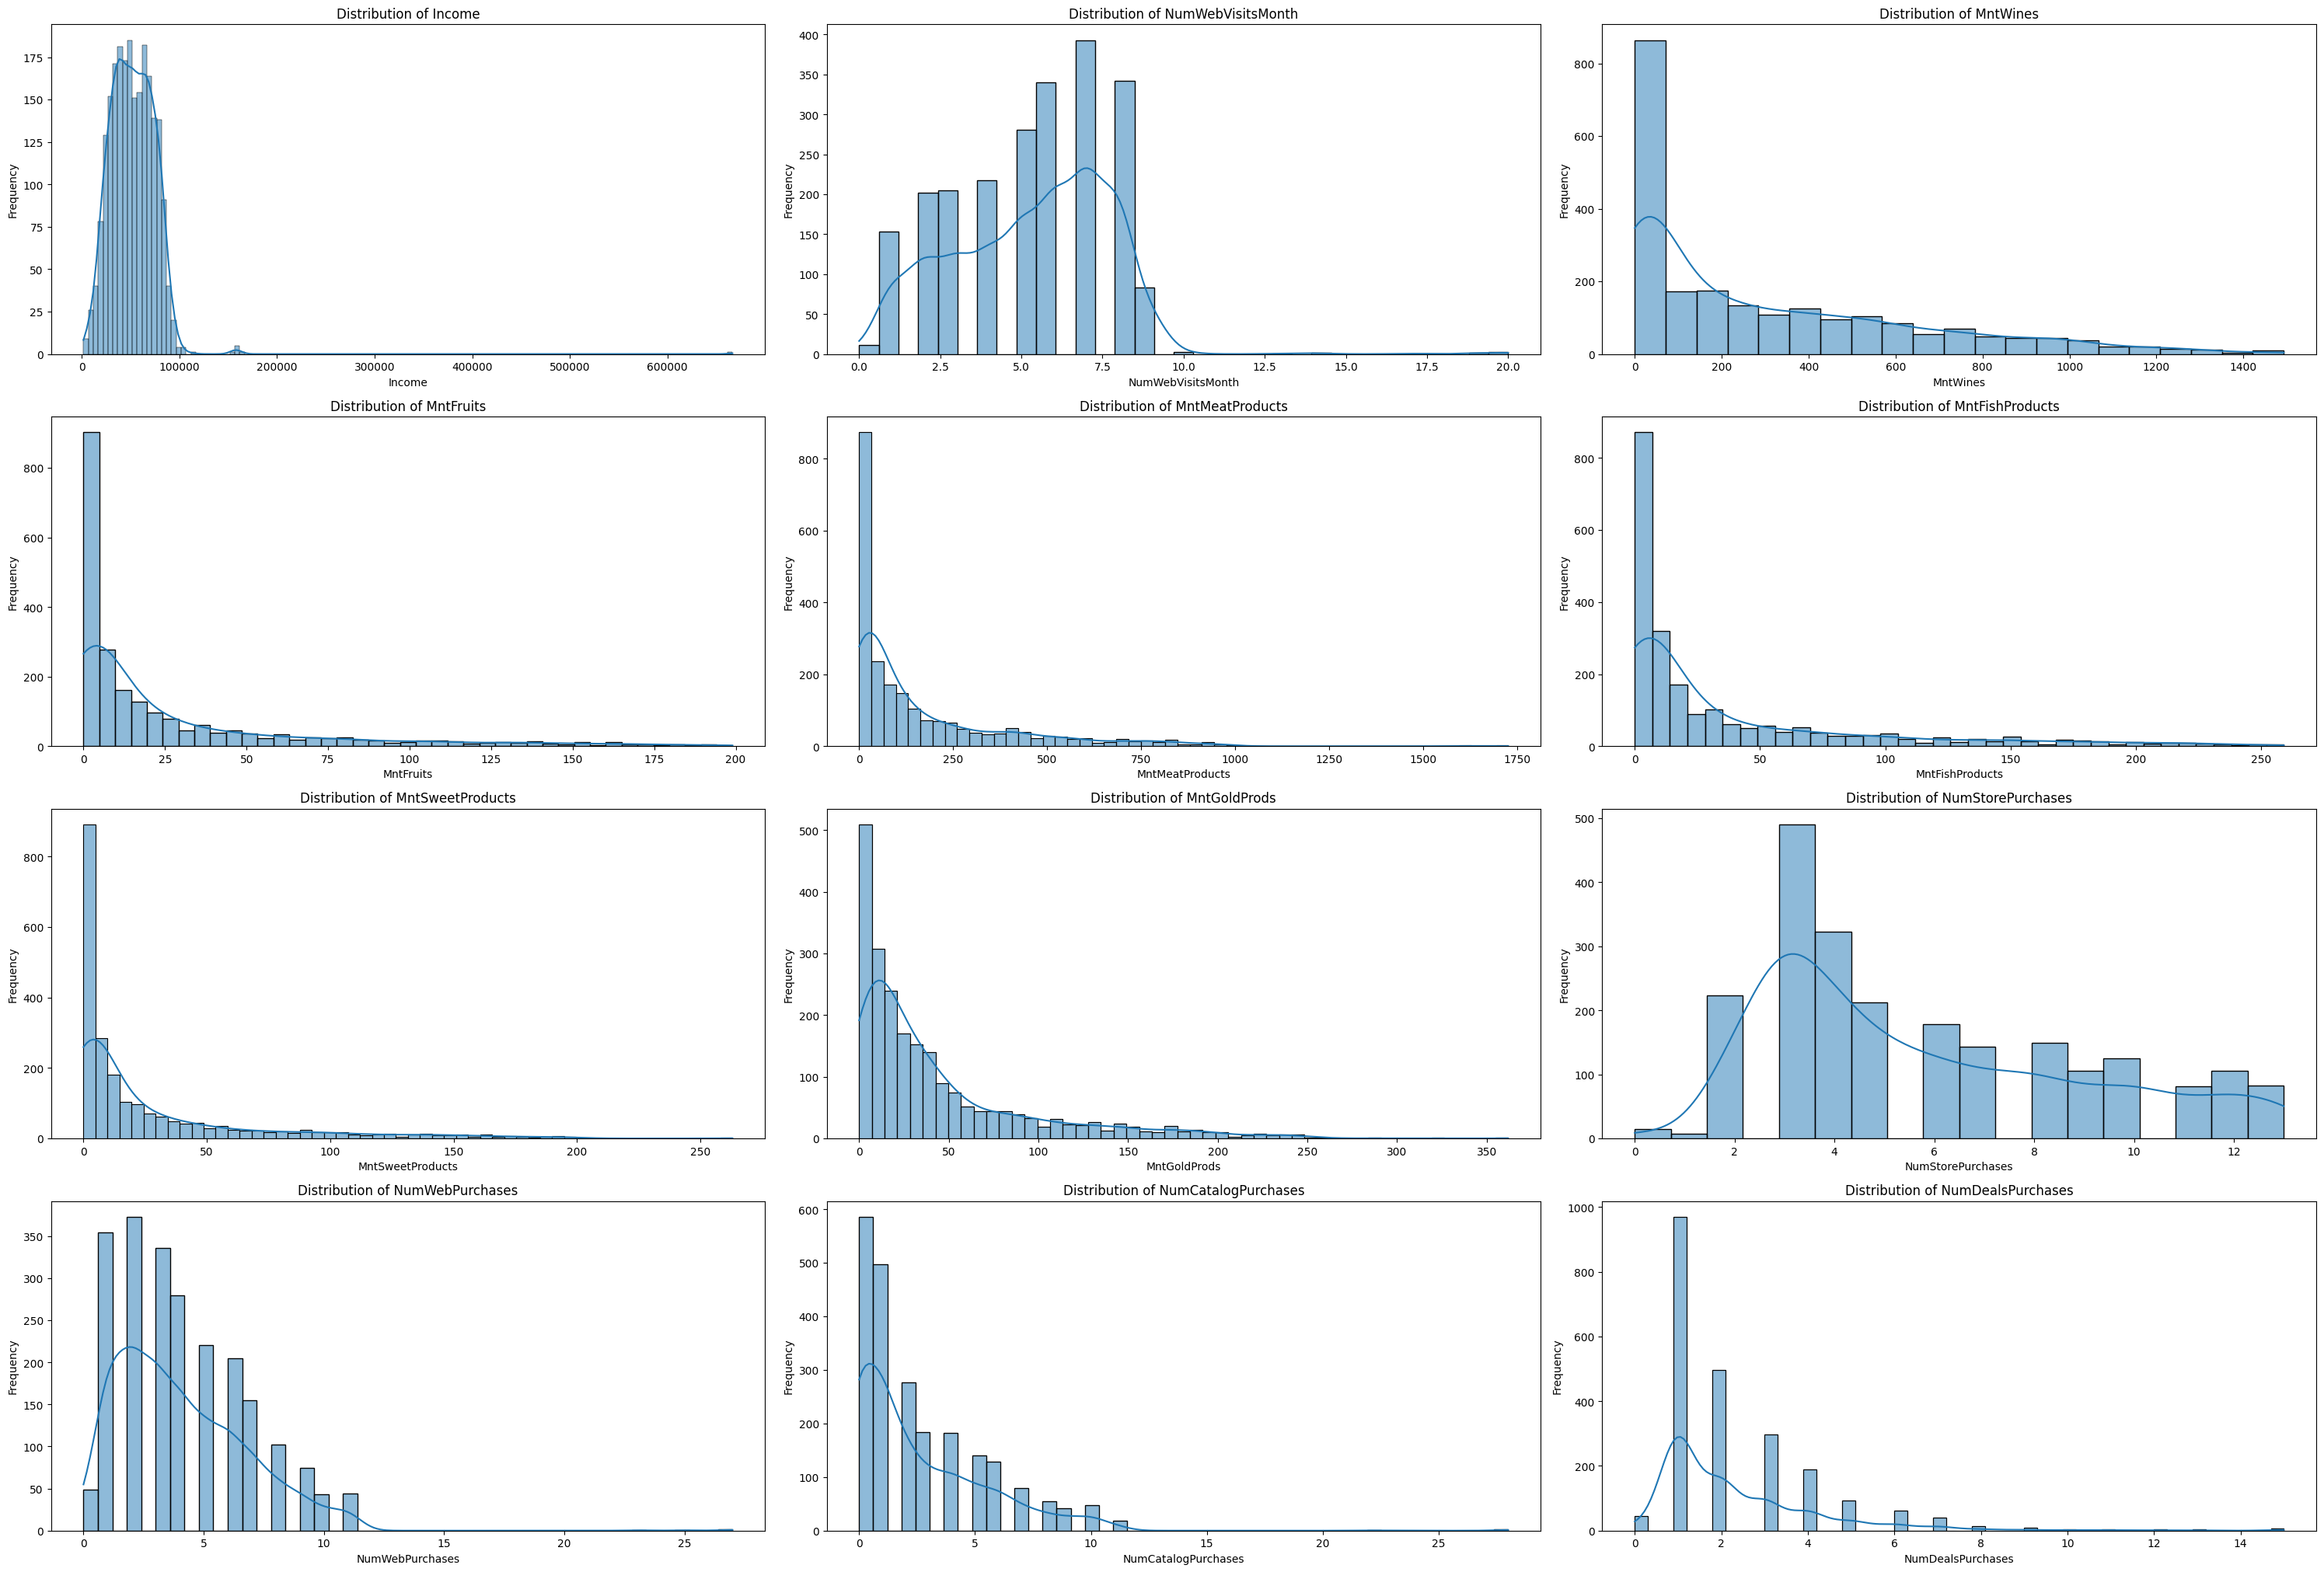

<Figure size 640x480 with 0 Axes>

In [ ]:
# Select numerical columns of interest

numerical_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]
plt.figure(figsize=(30, 30))
# Adjusted grid size to accommodate all 26 numerical columns (e.g., 6 rows * 5 columns = 30 plots)
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.savefig('histograms1.png') # In this environment, use savefig

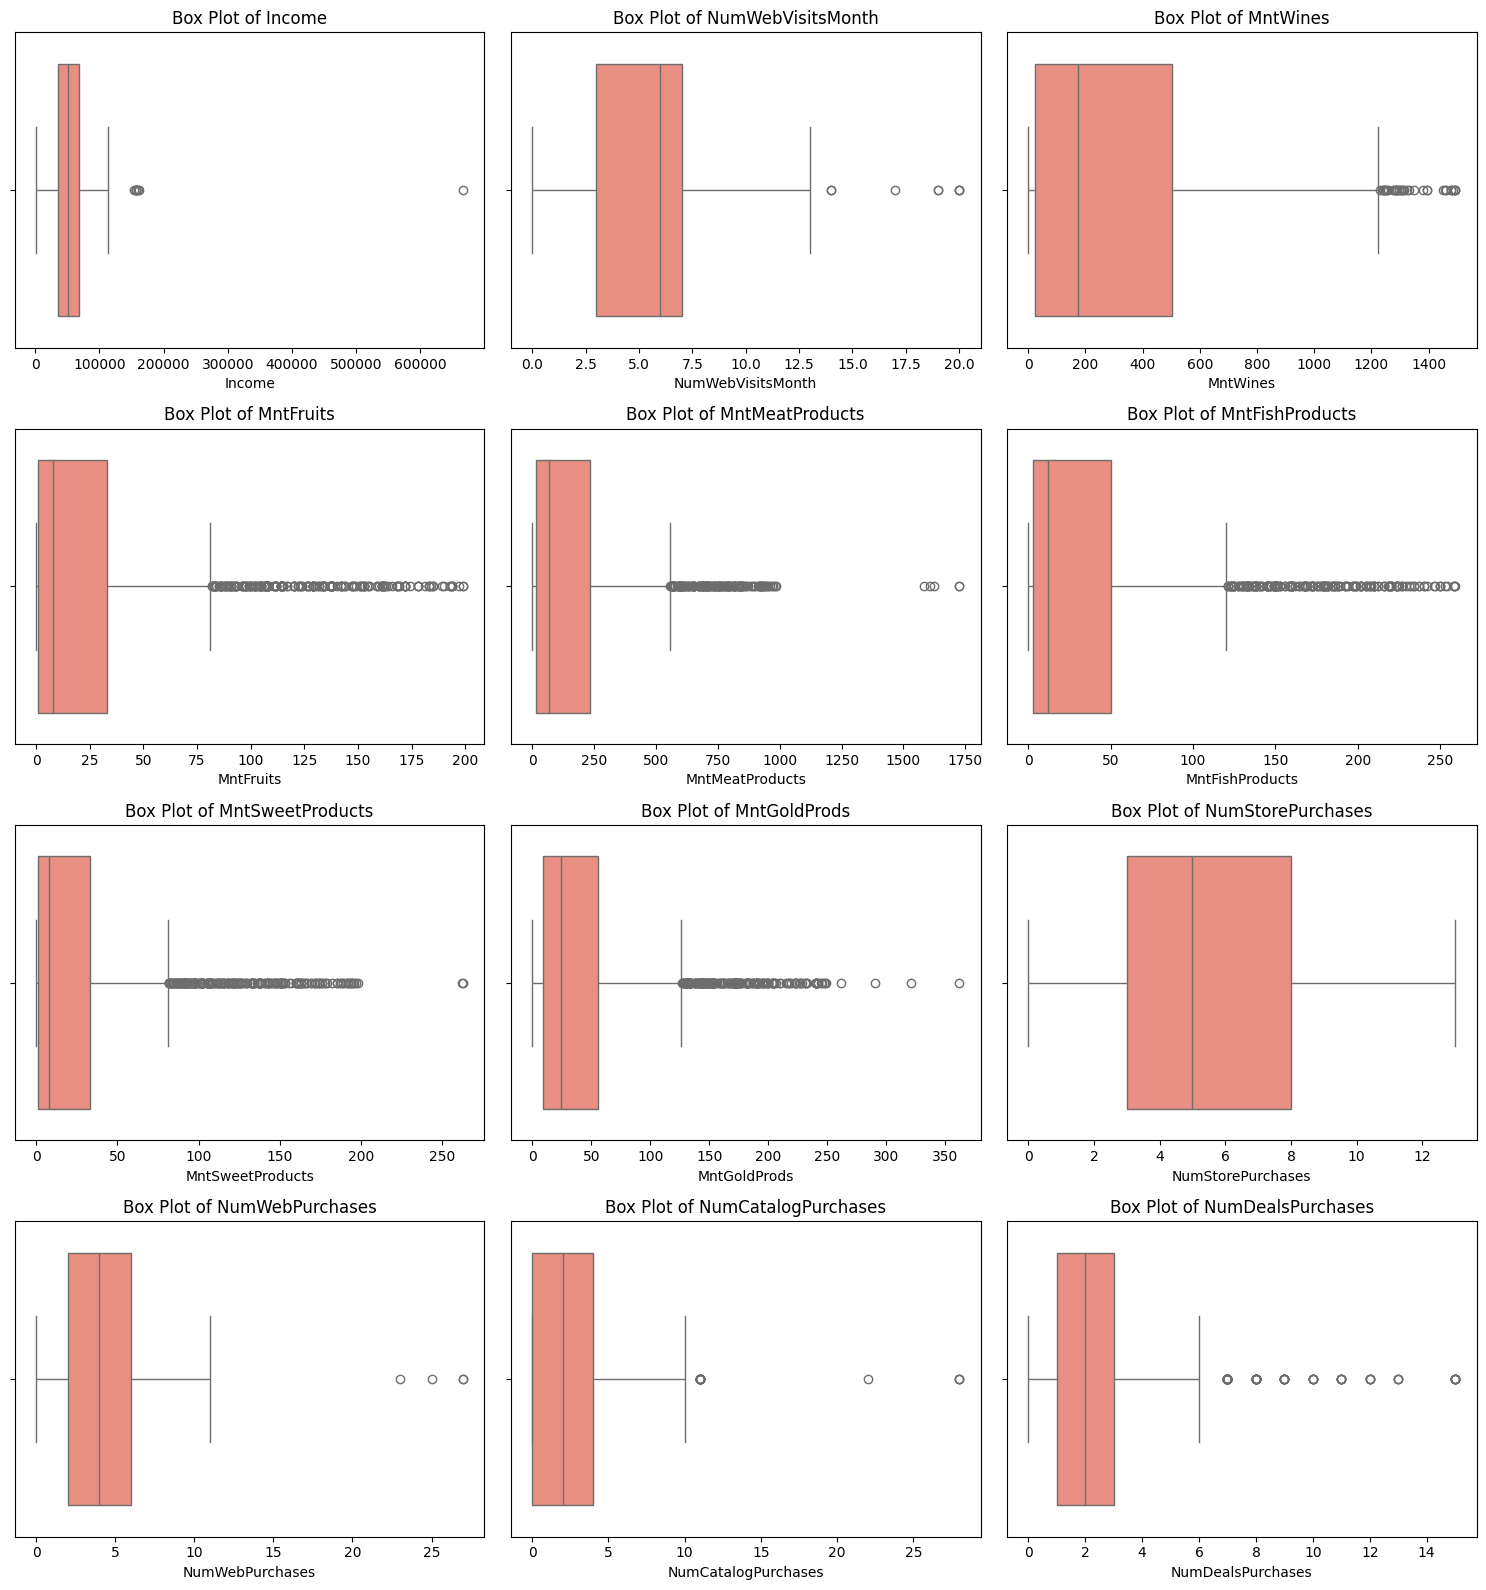

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]

# Dynamically calculate grid size (3 columns wide)
n_cols_per_row = 3
n_rows = math.ceil(len(numerical_cols) / n_cols_per_row)

# Generate Box plots
plt.figure(figsize=(n_cols_per_row * 5, n_rows * 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols_per_row, i)
    sns.boxplot(x=df[col].dropna(), color='salmon') # Using .dropna() for robustness
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.savefig('boxplots_selected_numerical.png') # Saving to a new file to avoid conflicts
plt.show()

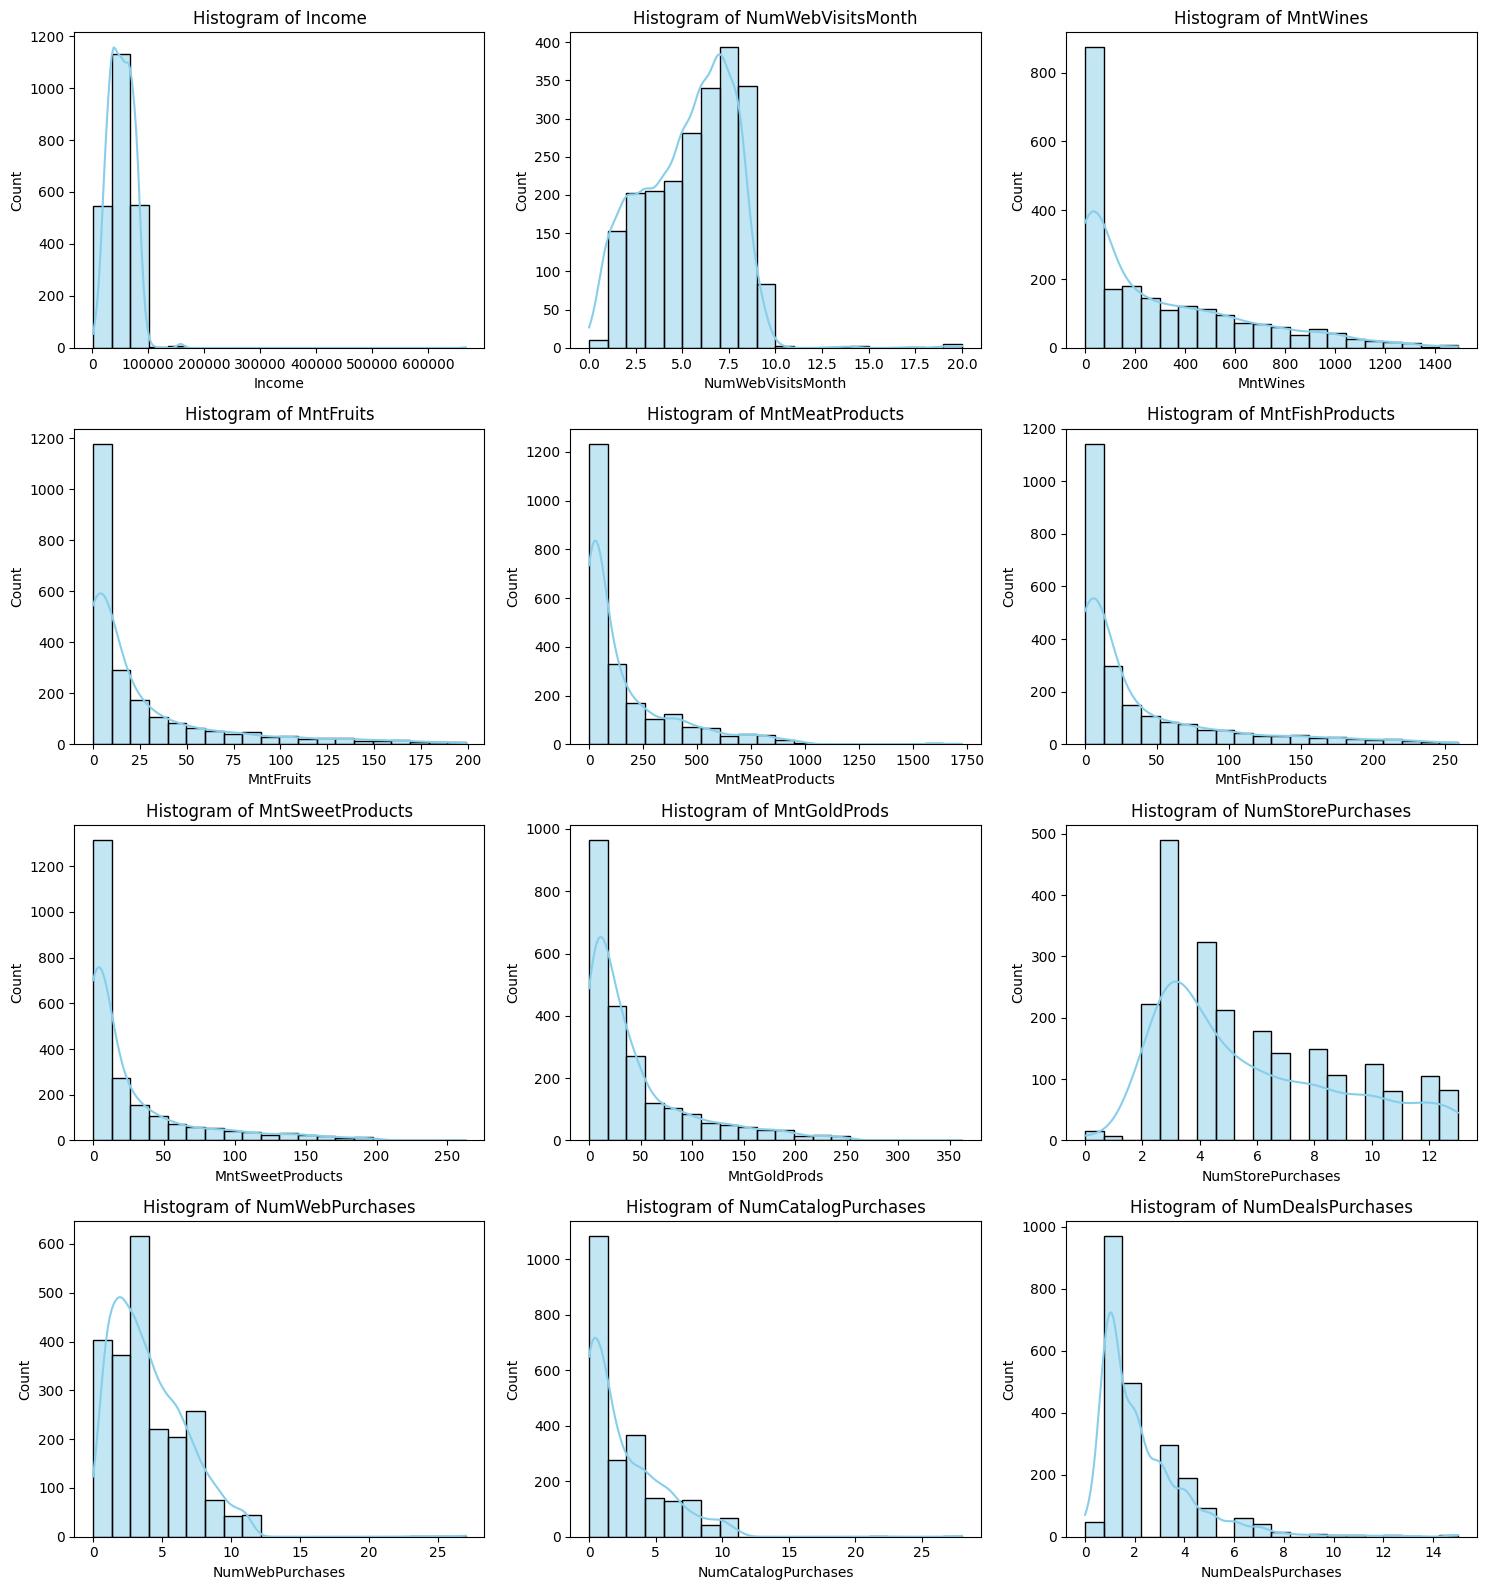

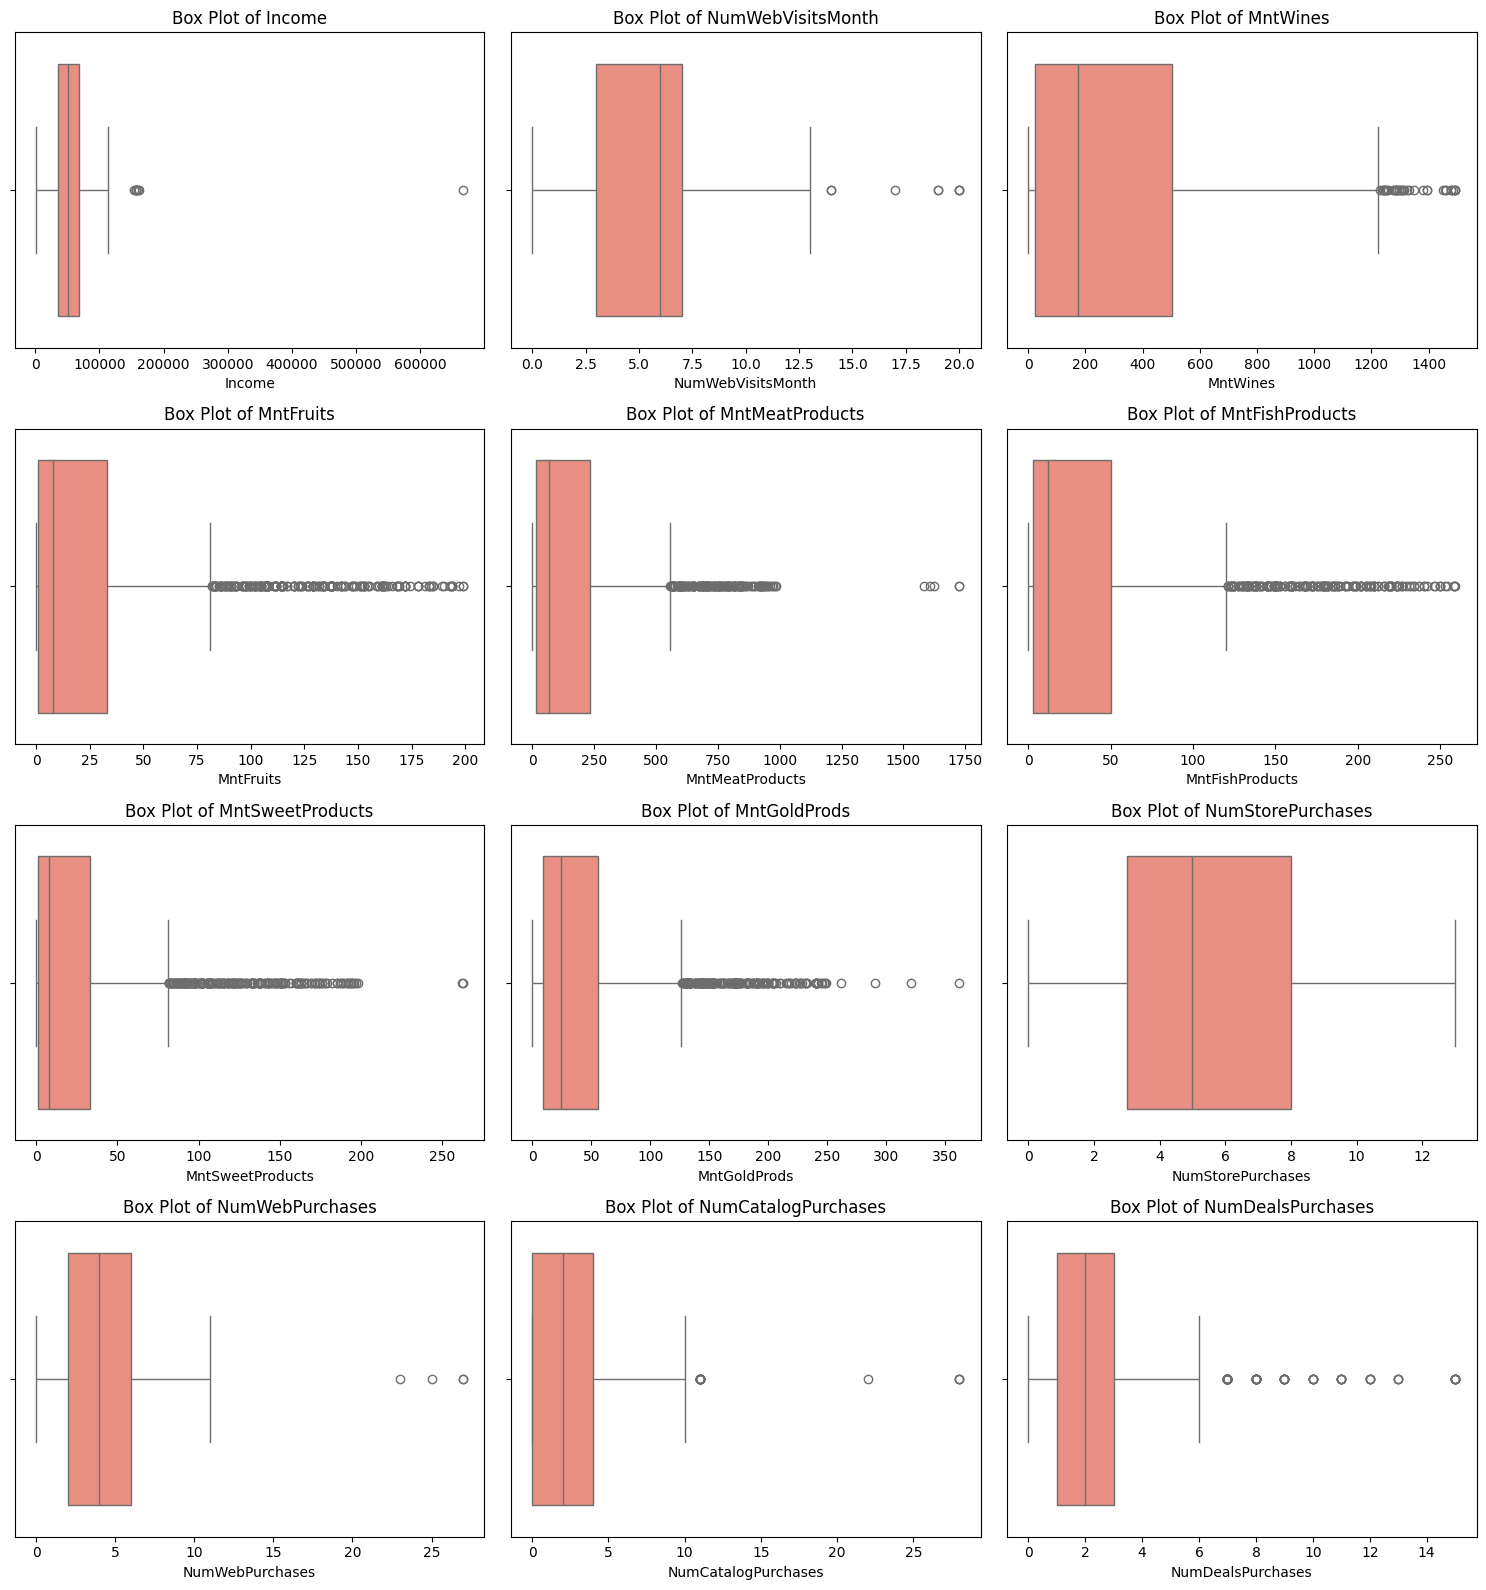

In [ ]:
# Select numerical columns of interest
numerical_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]

# Dynamically calculate grid size (3 columns wide)
n_rows = math.ceil(len(numerical_cols) / 3)

# 1. Histograms
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue')
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

# 2. Box plots
# A new figure will be created for box plots. If we don't, the box plots will be added to the histogram figure.
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, 3, i)
    sns.boxplot(x=df[col].dropna(), color='salmon')
    plt.title(f"Box Plot of {col}")
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

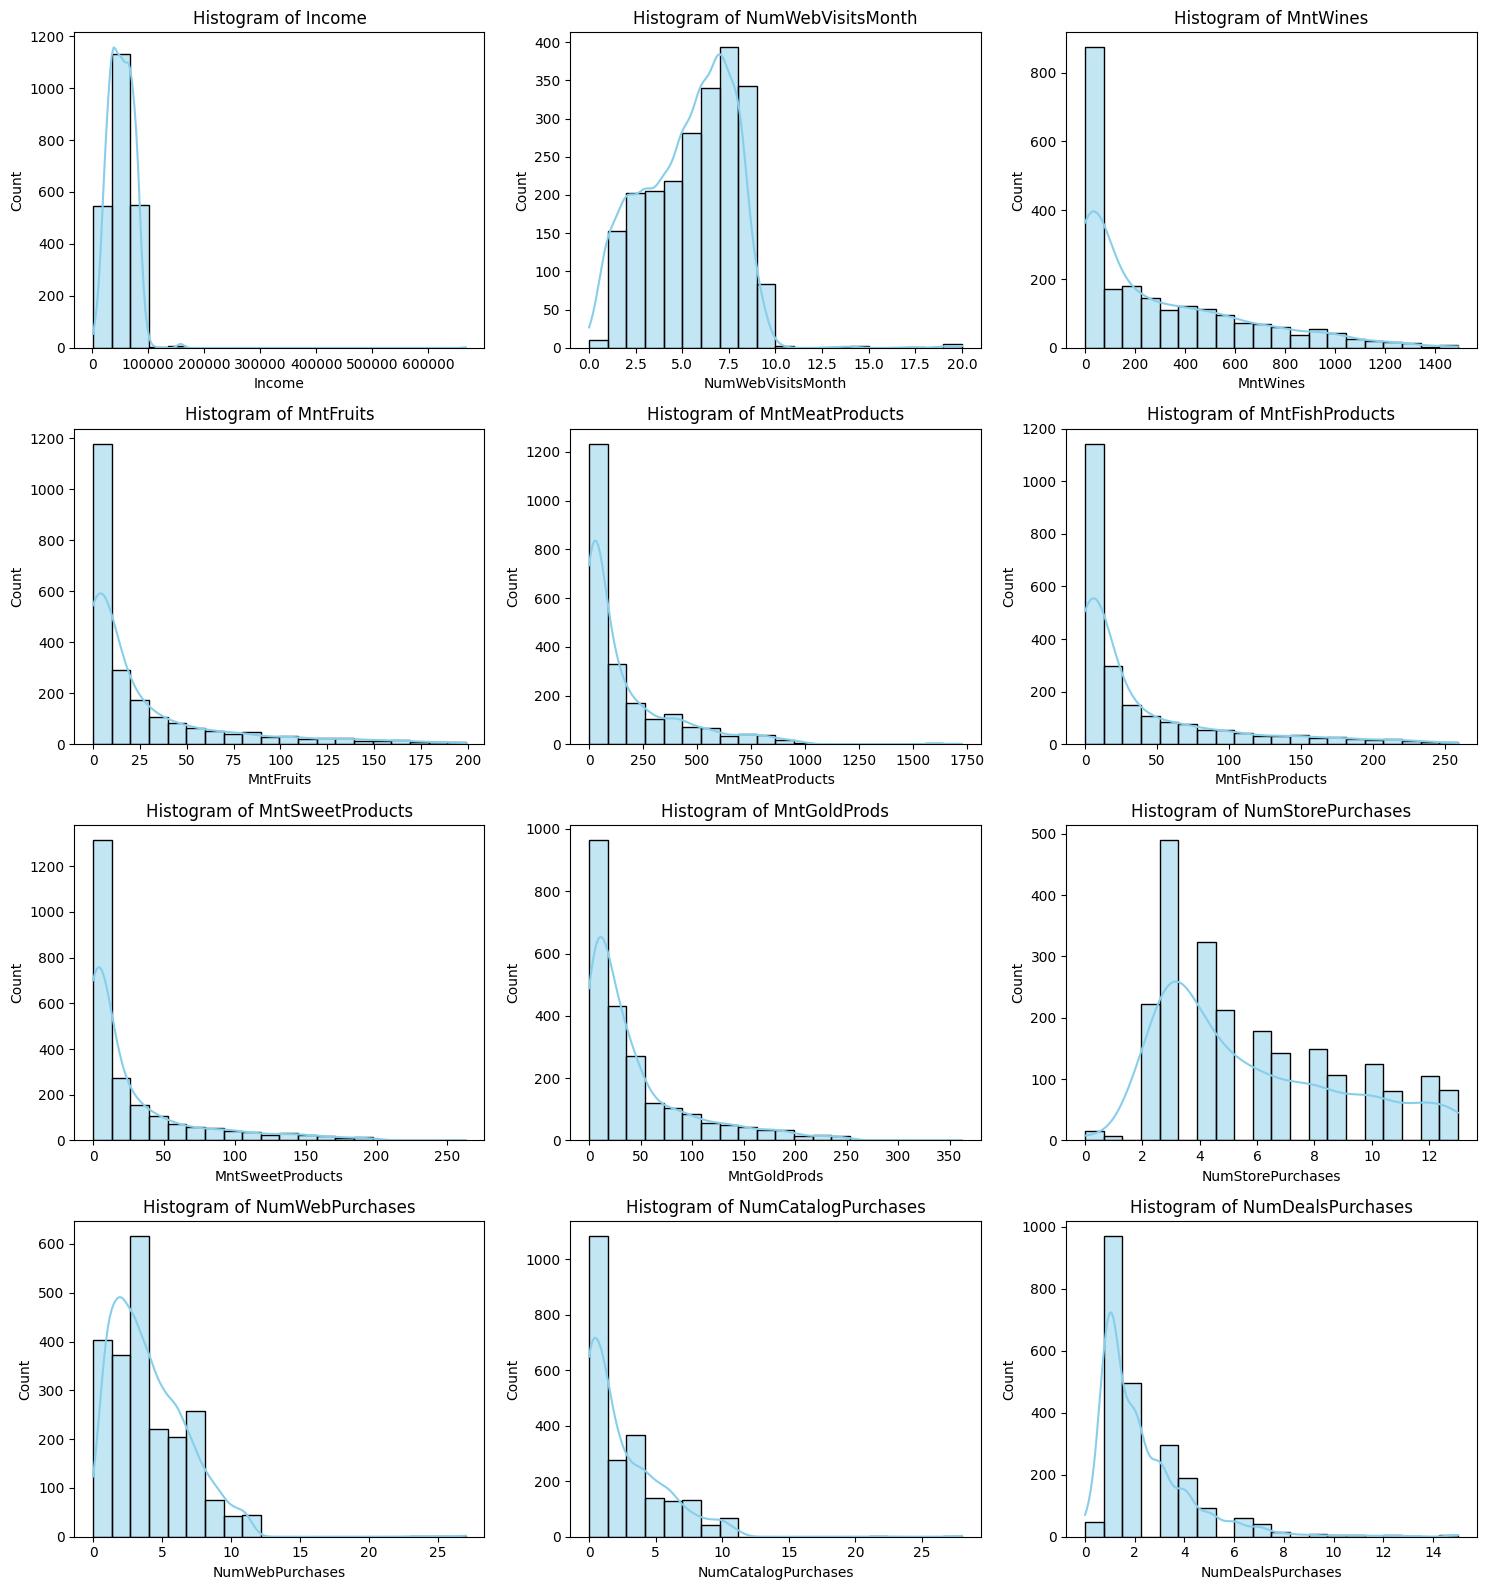

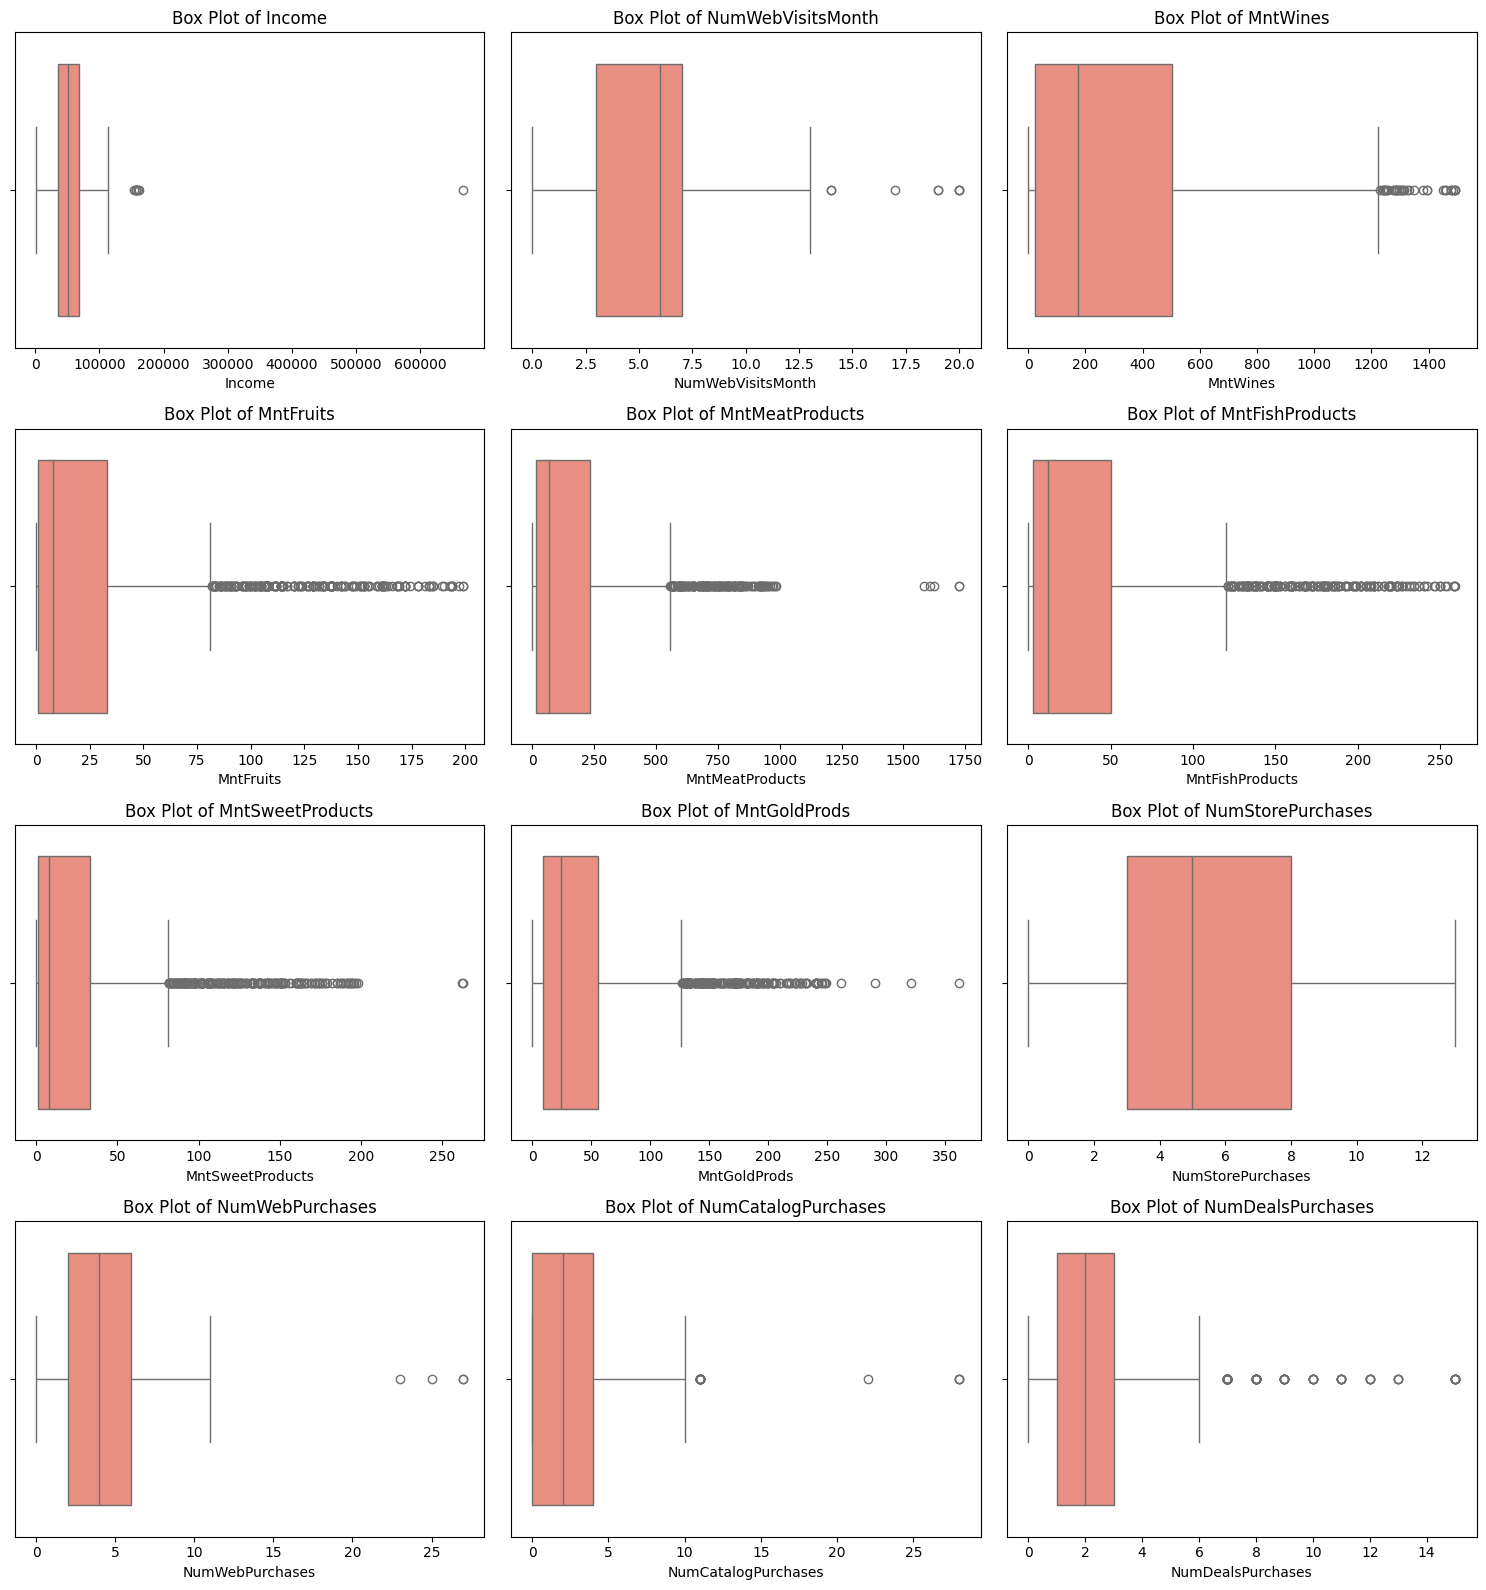

In [ ]:
# Select numerical columns of interest
num_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]

# Dynamically calculate grid size (3 columns wide)
n_rows = math.ceil(len(num_cols) / 3)  # Removed indentation here

# 1. Histograms
plt.figure(figsize=(15, n_rows * 4))  # Removed indentation here
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=20, color='skyblue')  # Changed df[num_cols] to df[col]
    plt.title(f"Histogram of {col}")  # Changed num_cols to col
plt.tight_layout()
lt.savefig('histograms.png') # In this environment, use savefig
p
# 2. Box plots
plt.figure(figsize=(15, n_rows * 4))  # Removed indentation here
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, 3, i)
    sns.boxplot(x=df[col].dropna(), color='salmon')  # Changed df[num_cols] to df[col]
    plt.title(f"Box Plot of {col}")  # Changed num_cols to col
plt.tight_layout()
plt.savefig('boxplots.png')


/tmp/ipython-input-747984906.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
/tmp/ipython-input-747984906.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
/tmp/ipython-input-747984906.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
/tmp/ipython-input-747984906.py:23: FutureWarning: 

Passing `palette` without assigning `h

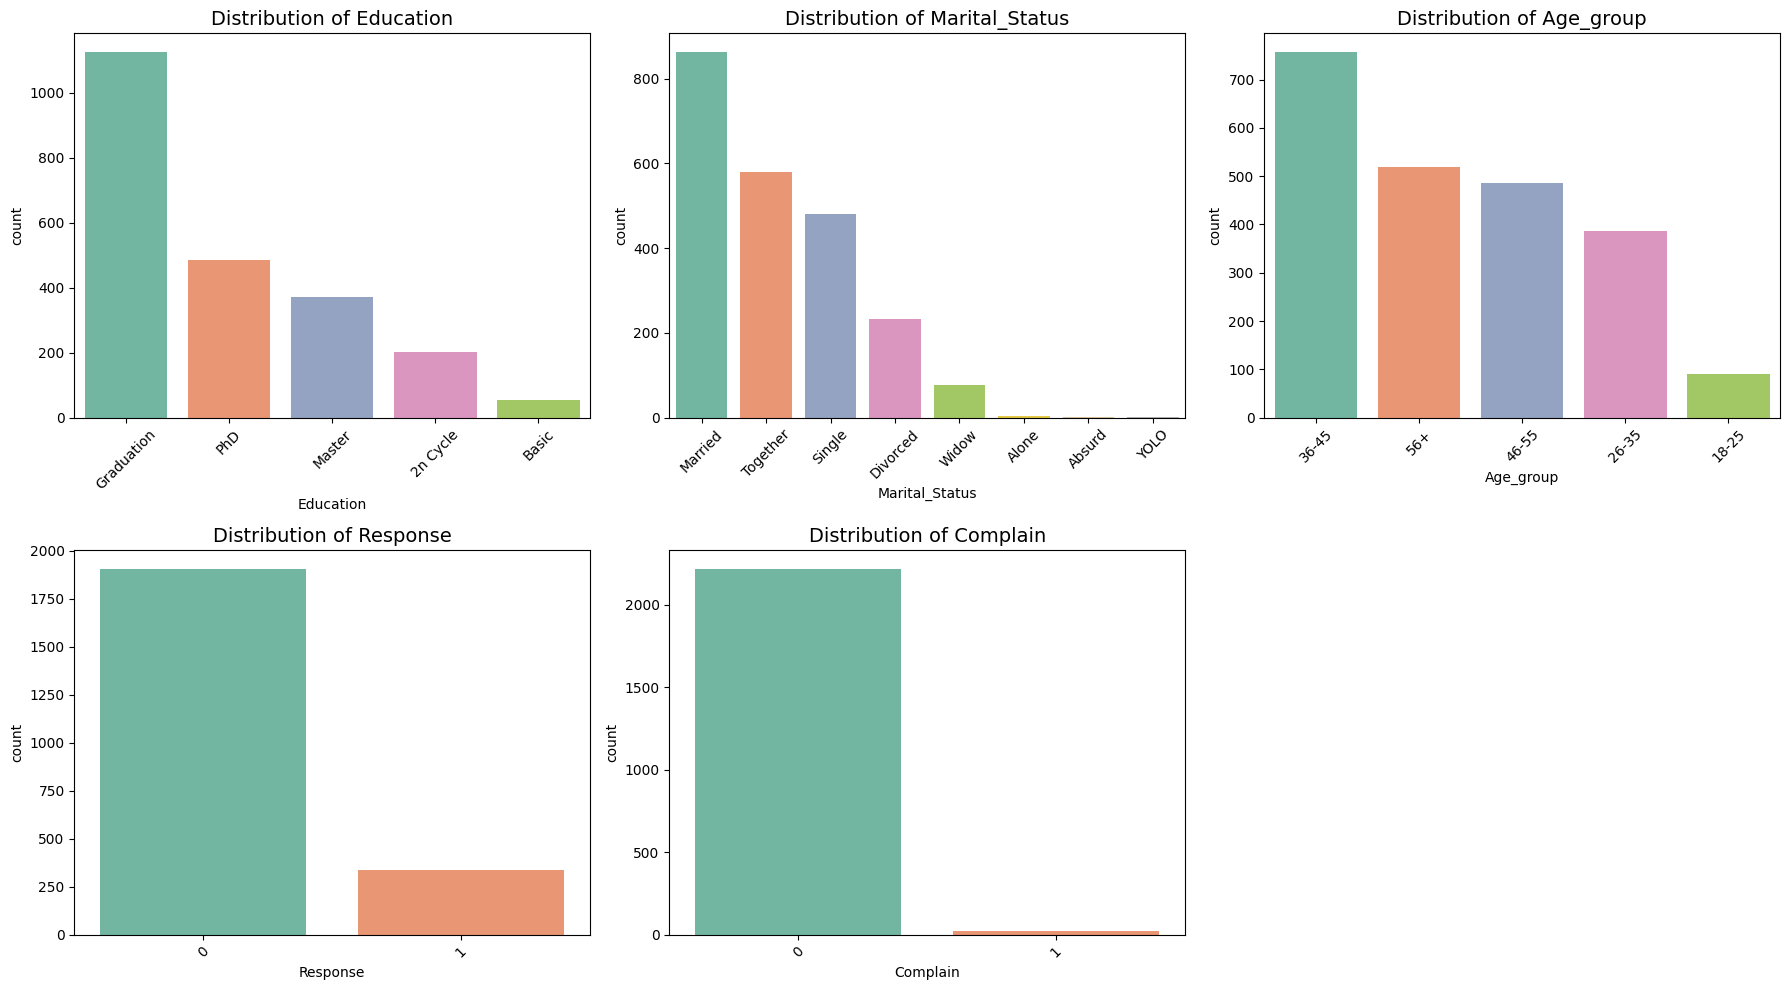

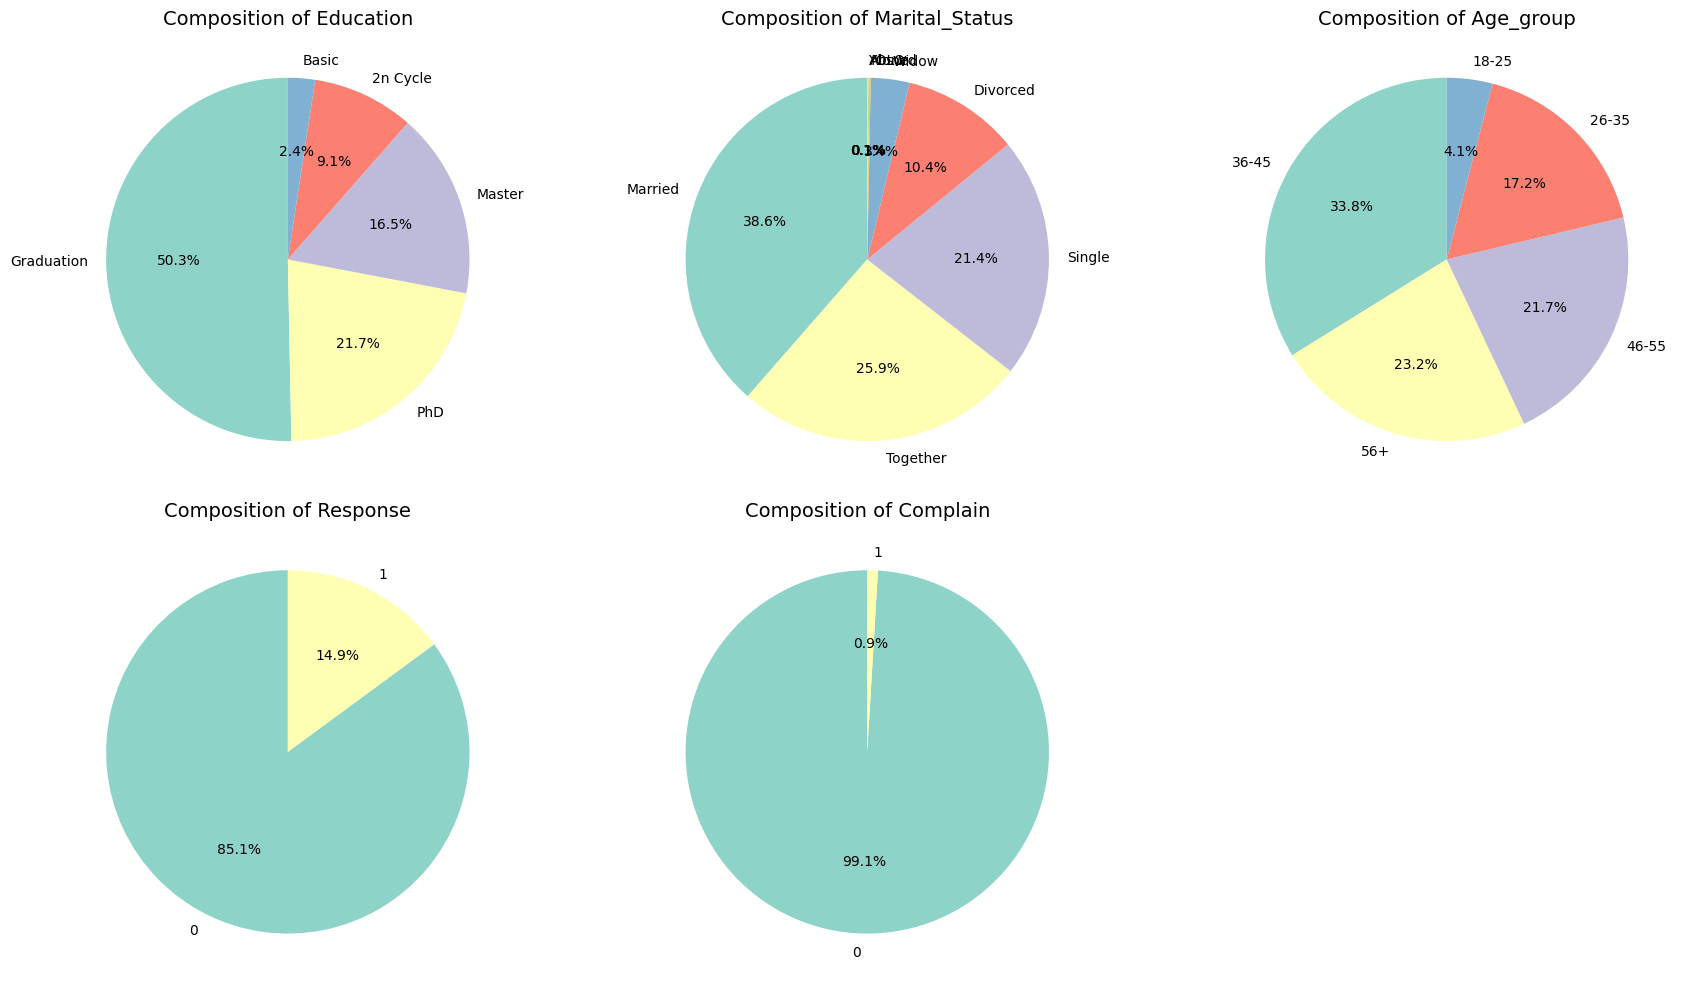

In [ ]:
# Explore the distribution of each categorical variable using bar plots or pie charts

# 1. Feature Engineering: Dates and Age
# Using dayfirst=True to handle the 'DD-MM-YYYY' format correctly
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df["Age"] = 2014 - df["Year_Birth"]  # Using 2015 as a reference year for age

# 2. Categorize Age into groups
df["Age_group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 130],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

# 3. Define categorical columns for plotting
cat_cols = ["Education", "Marital_Status", "Age_group", "Response", "Complain"]

# 4. Generate Bar Plots
plt.figure(figsize=(18, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    # Order bars by frequency
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('categorical_bar_plots.png')

# 5. Generate Pie Charts
plt.figure(figsize=(18, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
    plt.title(f"Composition of {col}", fontsize=14)
plt.tight_layout()
plt.savefig('categorical_pie_charts.png')



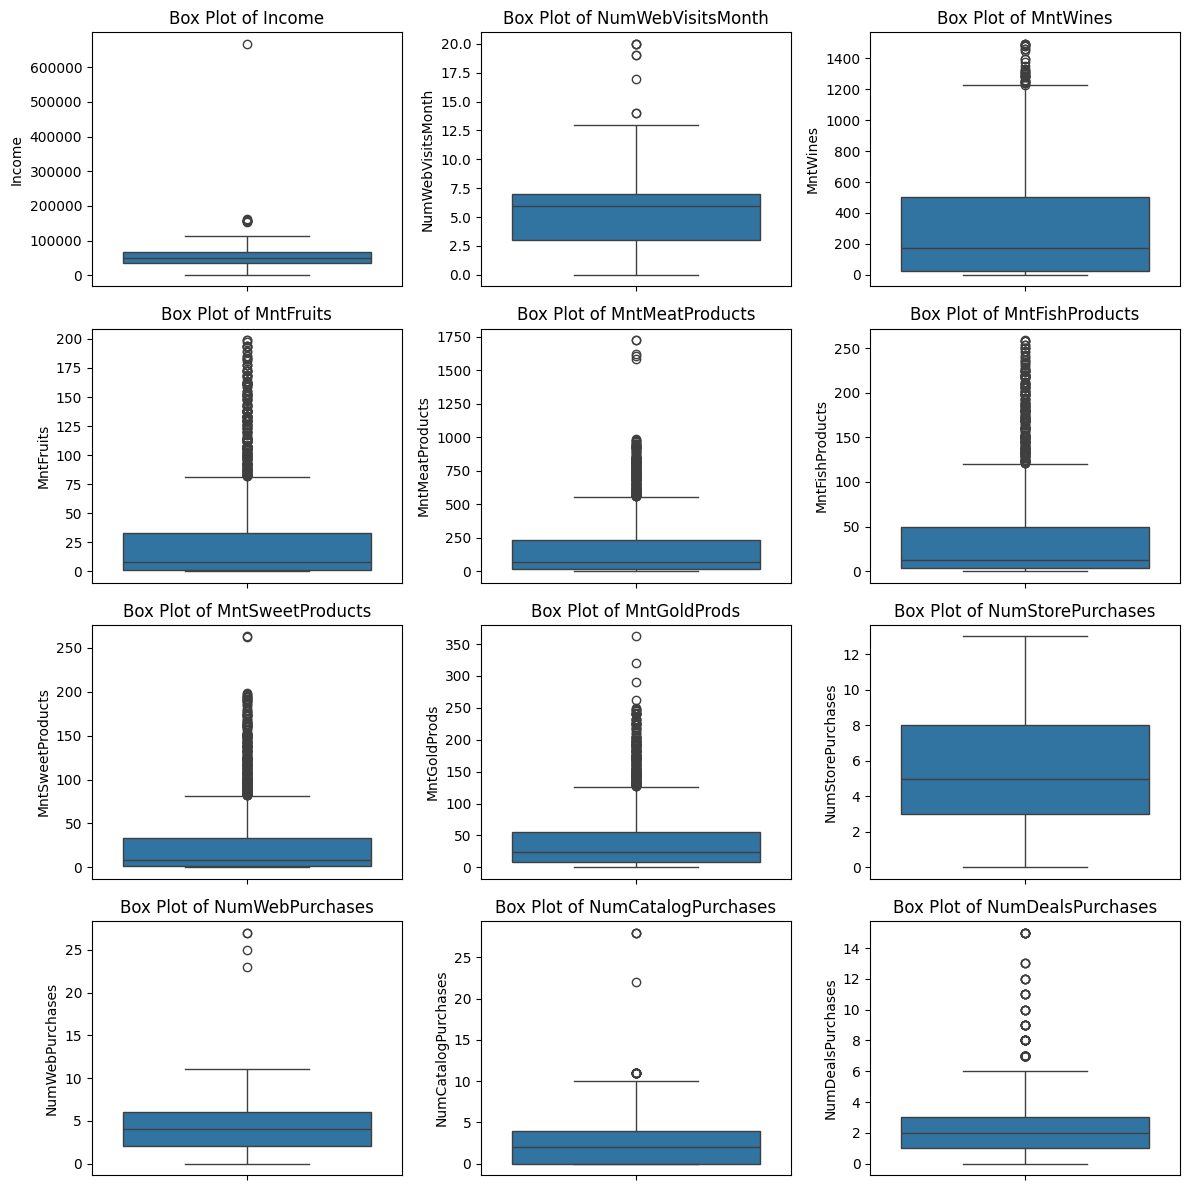

In [ ]:
numerical_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]
# Dynamically calculate grid size for box plots (e.g., 5 columns wide)
n_cols_per_row = 3
n_rows = math.ceil(len(numerical_cols) / n_cols_per_row)

plt.figure(figsize=(n_cols_per_row * 4, n_rows * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols_per_row, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

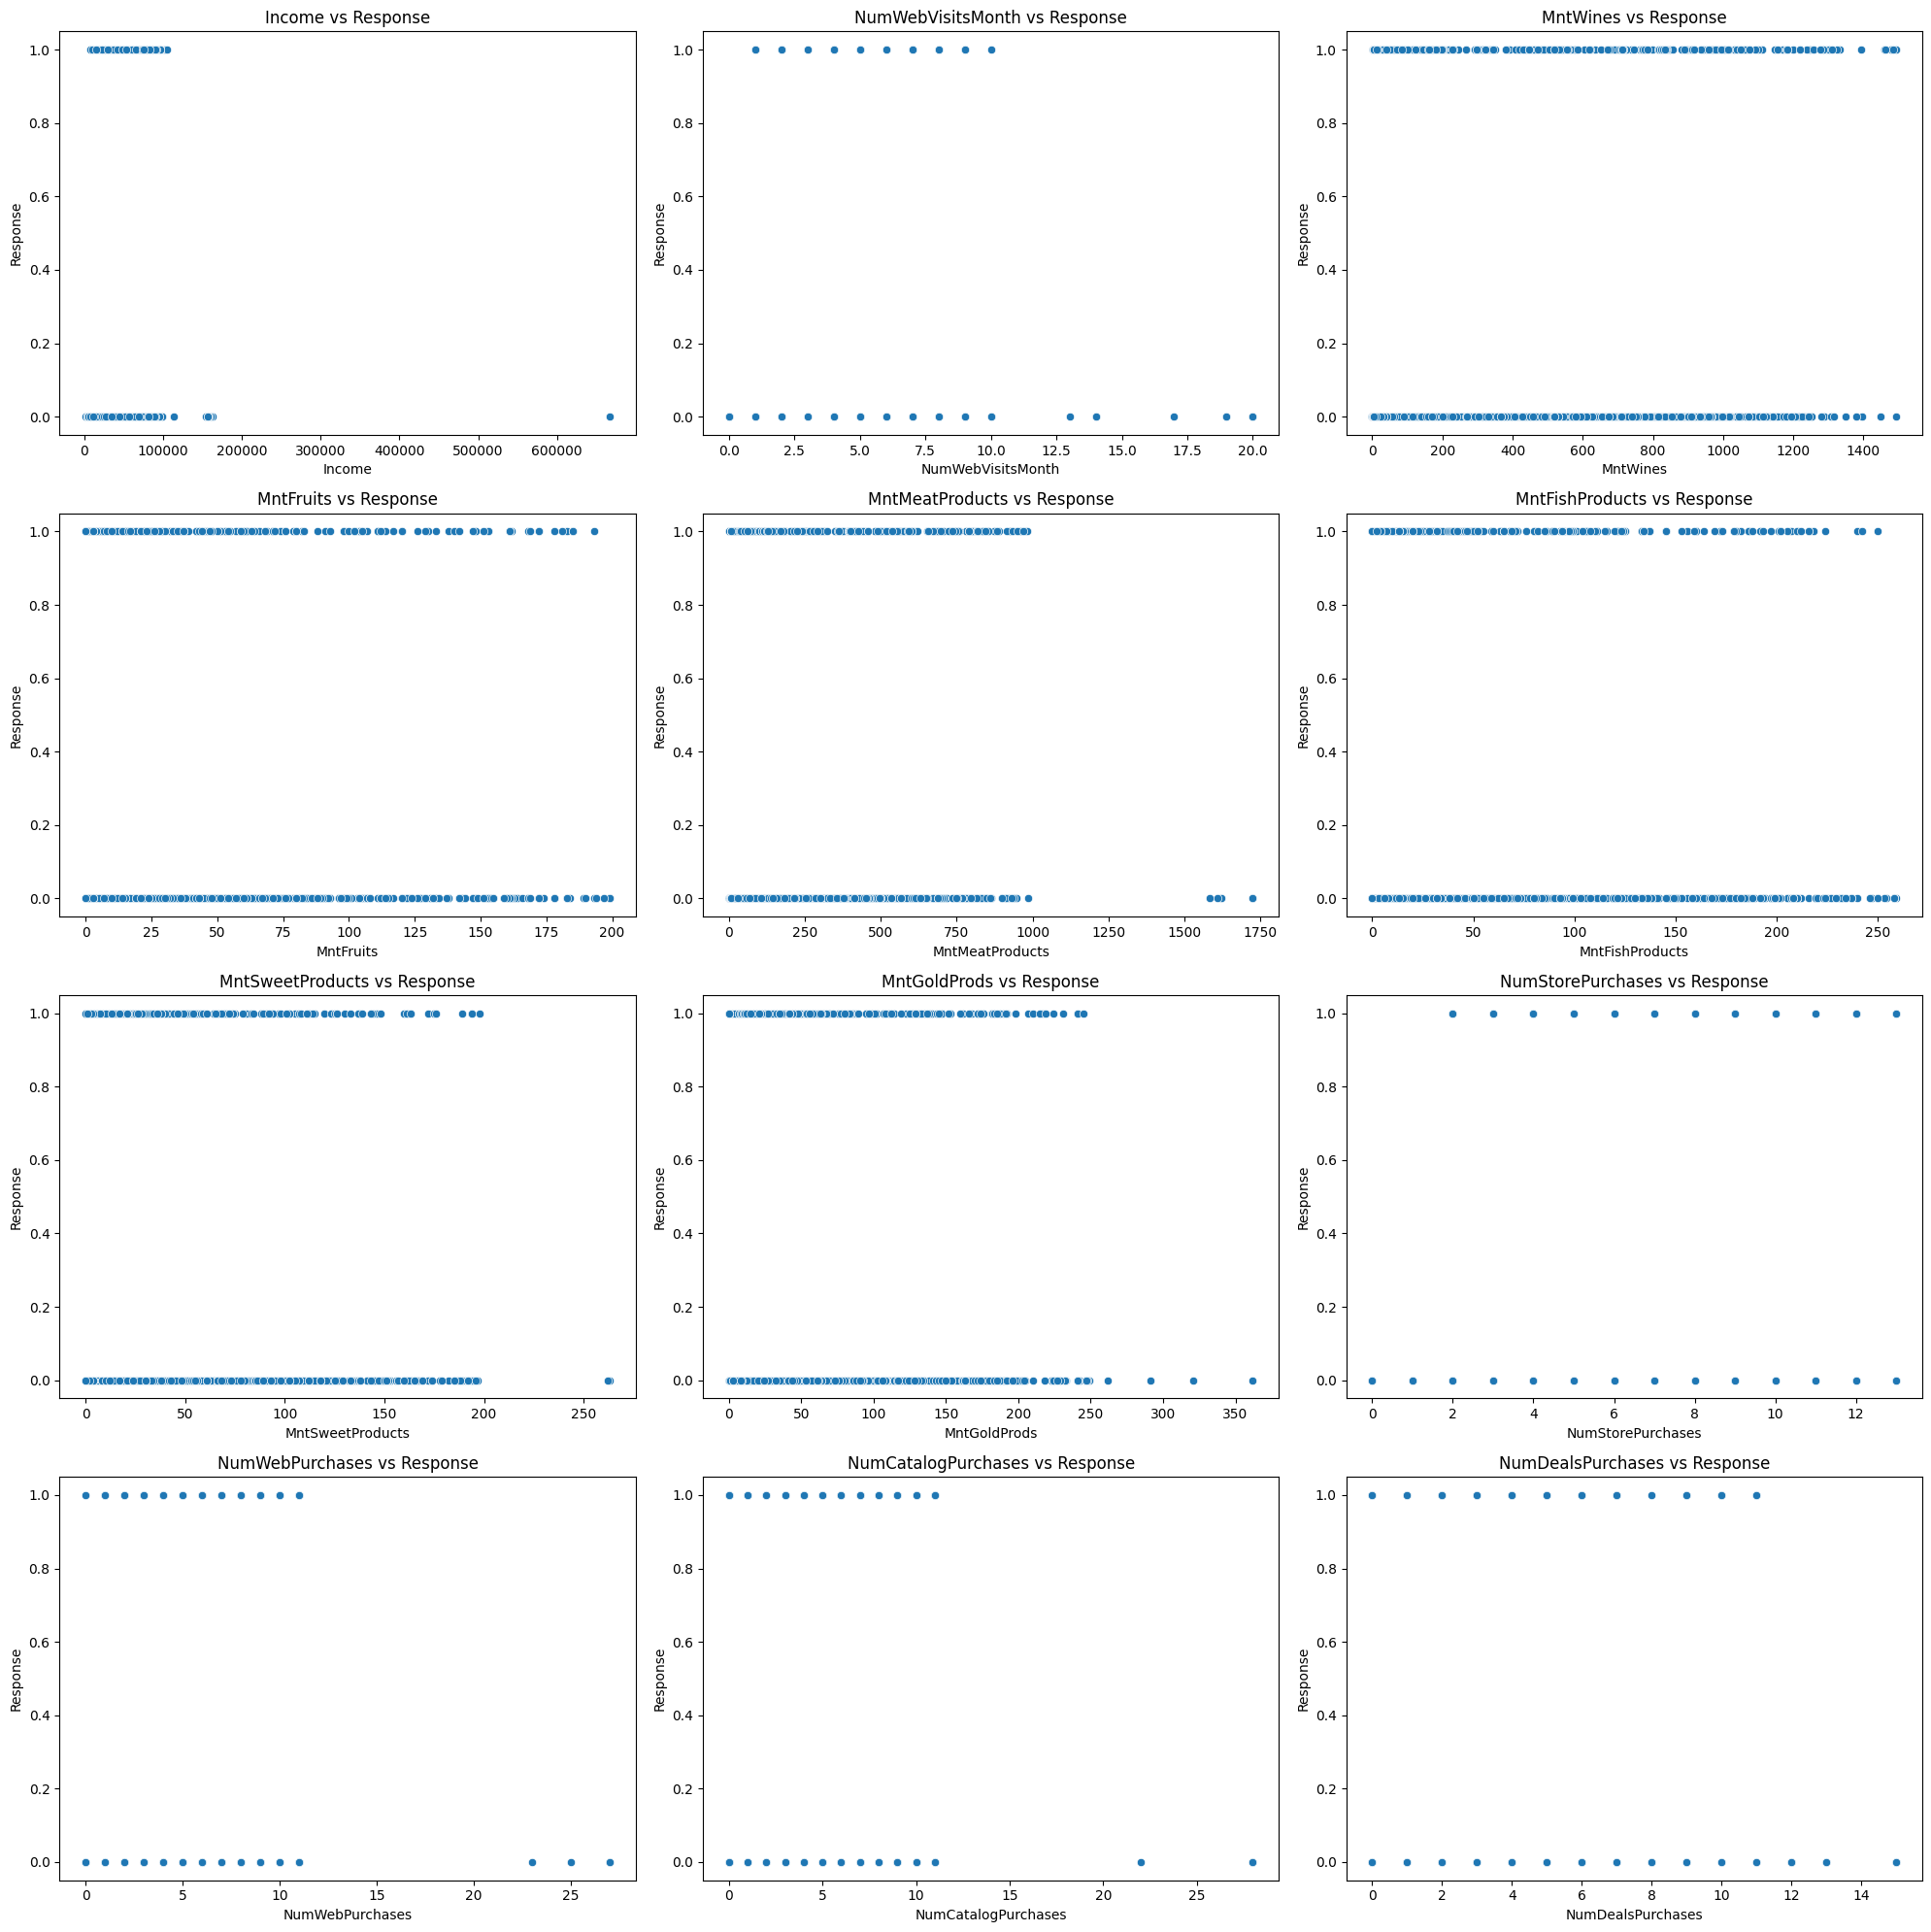

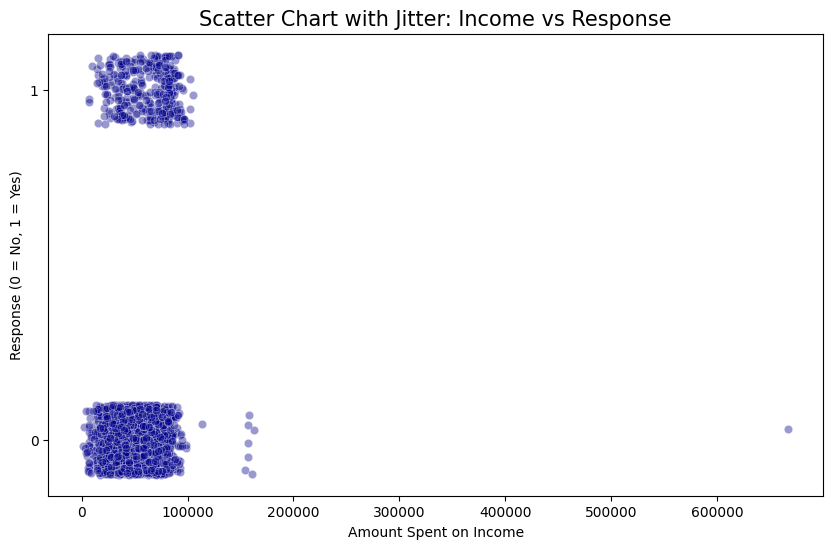

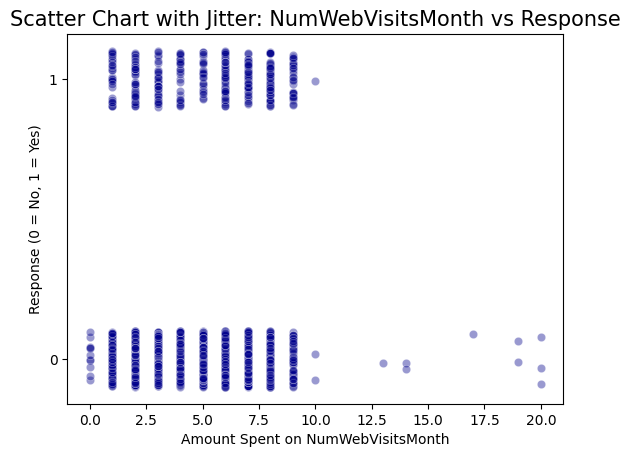

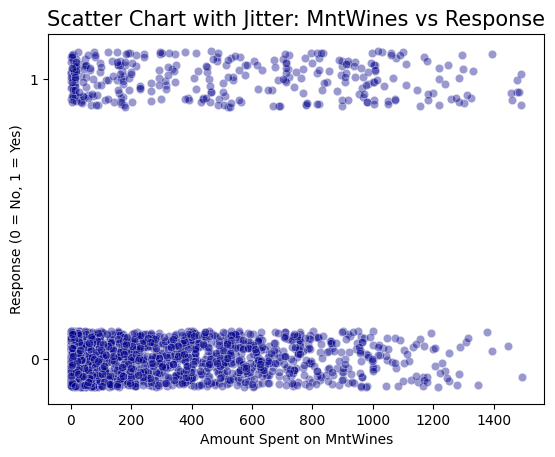

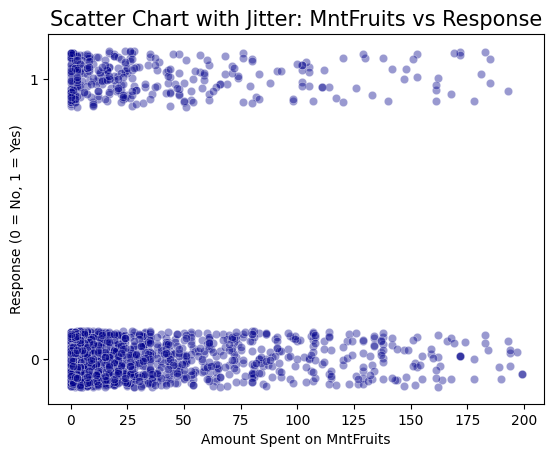

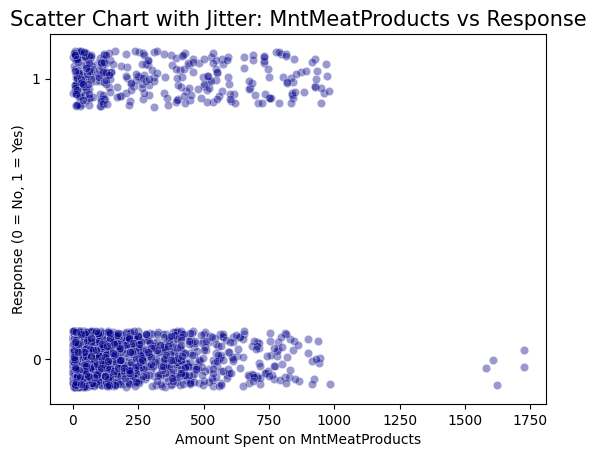

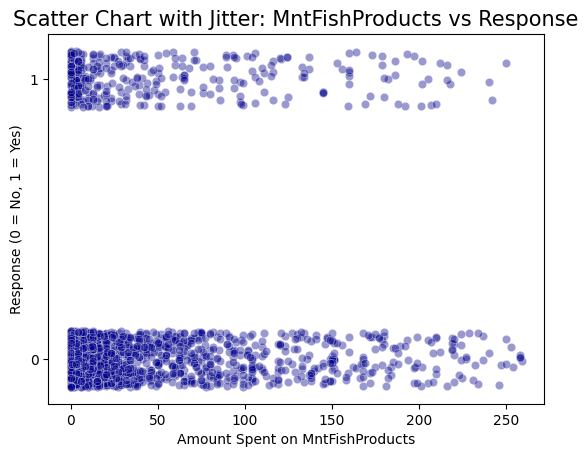

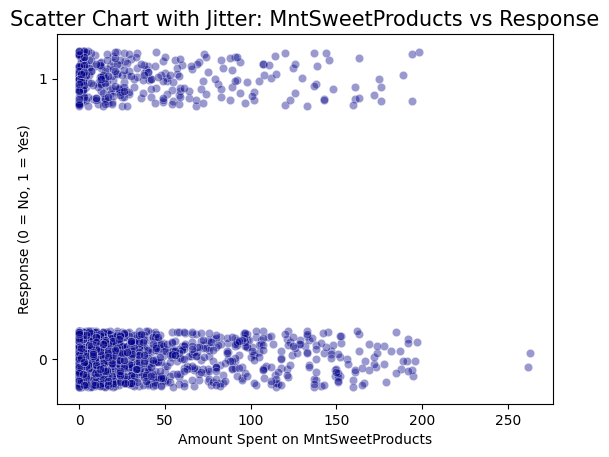

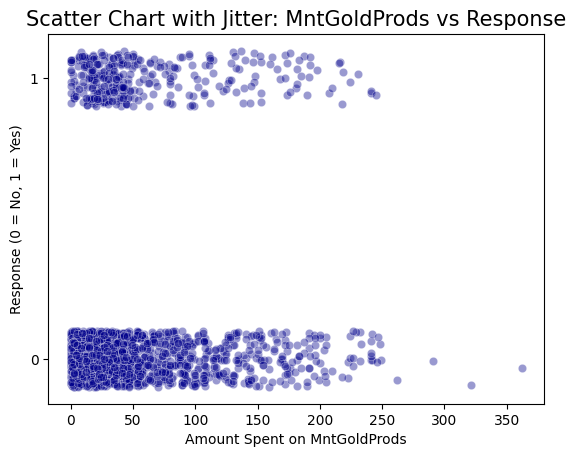

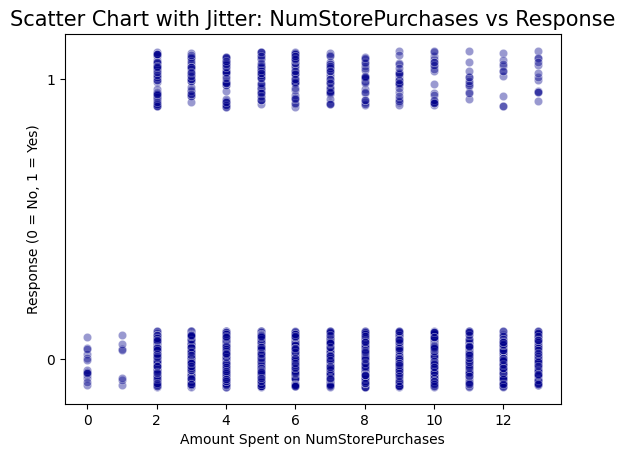

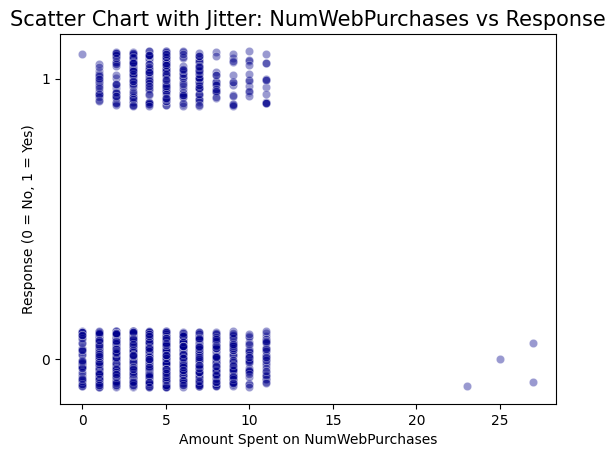

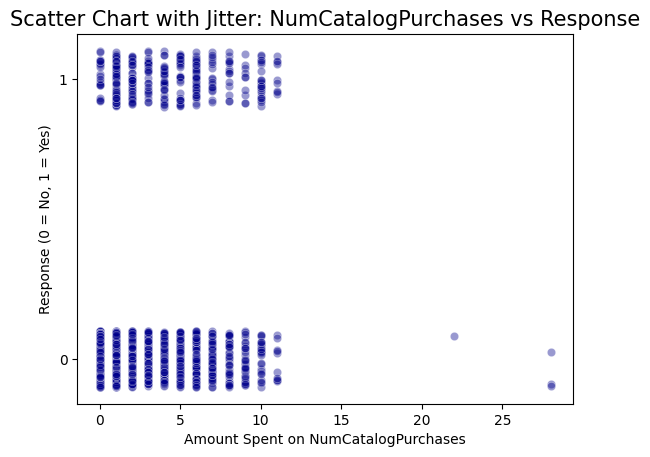

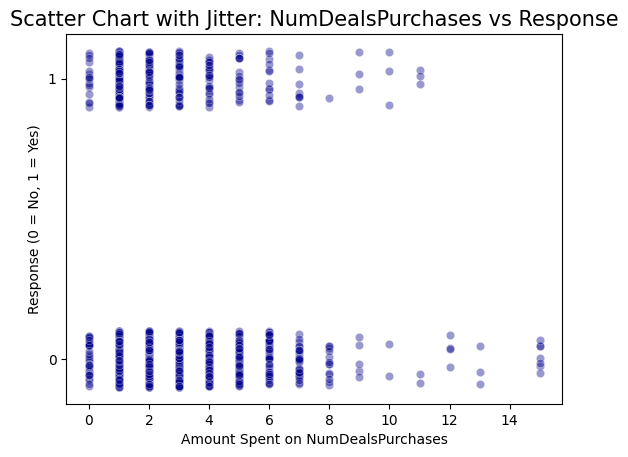

In [ ]:
numerical_cols = ["Income","NumWebVisitsMonth", "MntWines",
            "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
            "NumStorePurchases", "NumWebPurchases",
            "NumCatalogPurchases", "NumDealsPurchases"]
# Exclude 'Response' from the list if it's already in numerical_cols to plot against it
if 'Response' in numerical_cols:
    numerical_cols.remove('Response')

# Scatter plots of numerical features vs Response
plt.figure(figsize=(20, 20))
n_cols_per_row = 3
n_rows = math.ceil(len(numerical_cols) / n_cols_per_row)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols_per_row, i + 1)
    sns.scatterplot(x=df[col], y=df['Response'])
    plt.title(f'{col} vs Response')
    plt.xlabel(col)
    plt.ylabel('Response')
plt.tight_layout()
plt.savefig('numerical_vs_response_scatter.png')
plt.show()


plt.figure(figsize=(10, 6))
for i, col in enumerate(numerical_cols):
    # We add a small random 'jitter' to the Y-axis (Response) to see overlapping points
    sns.scatterplot(x=df[col],
                    y=df['Response'] + np.random.uniform(-0.1, 0.1, size=len(df)), # Corrected size=len(df)
                    alpha=0.4, color='darkblue')

    plt.title(f'Scatter Chart with Jitter: {col} vs Response', fontsize=15)
    plt.xlabel(f'Amount Spent on {col}')
    plt.ylabel('Response (0 = No, 1 = Yes)')
    plt.yticks([0, 1])
    plt.show()

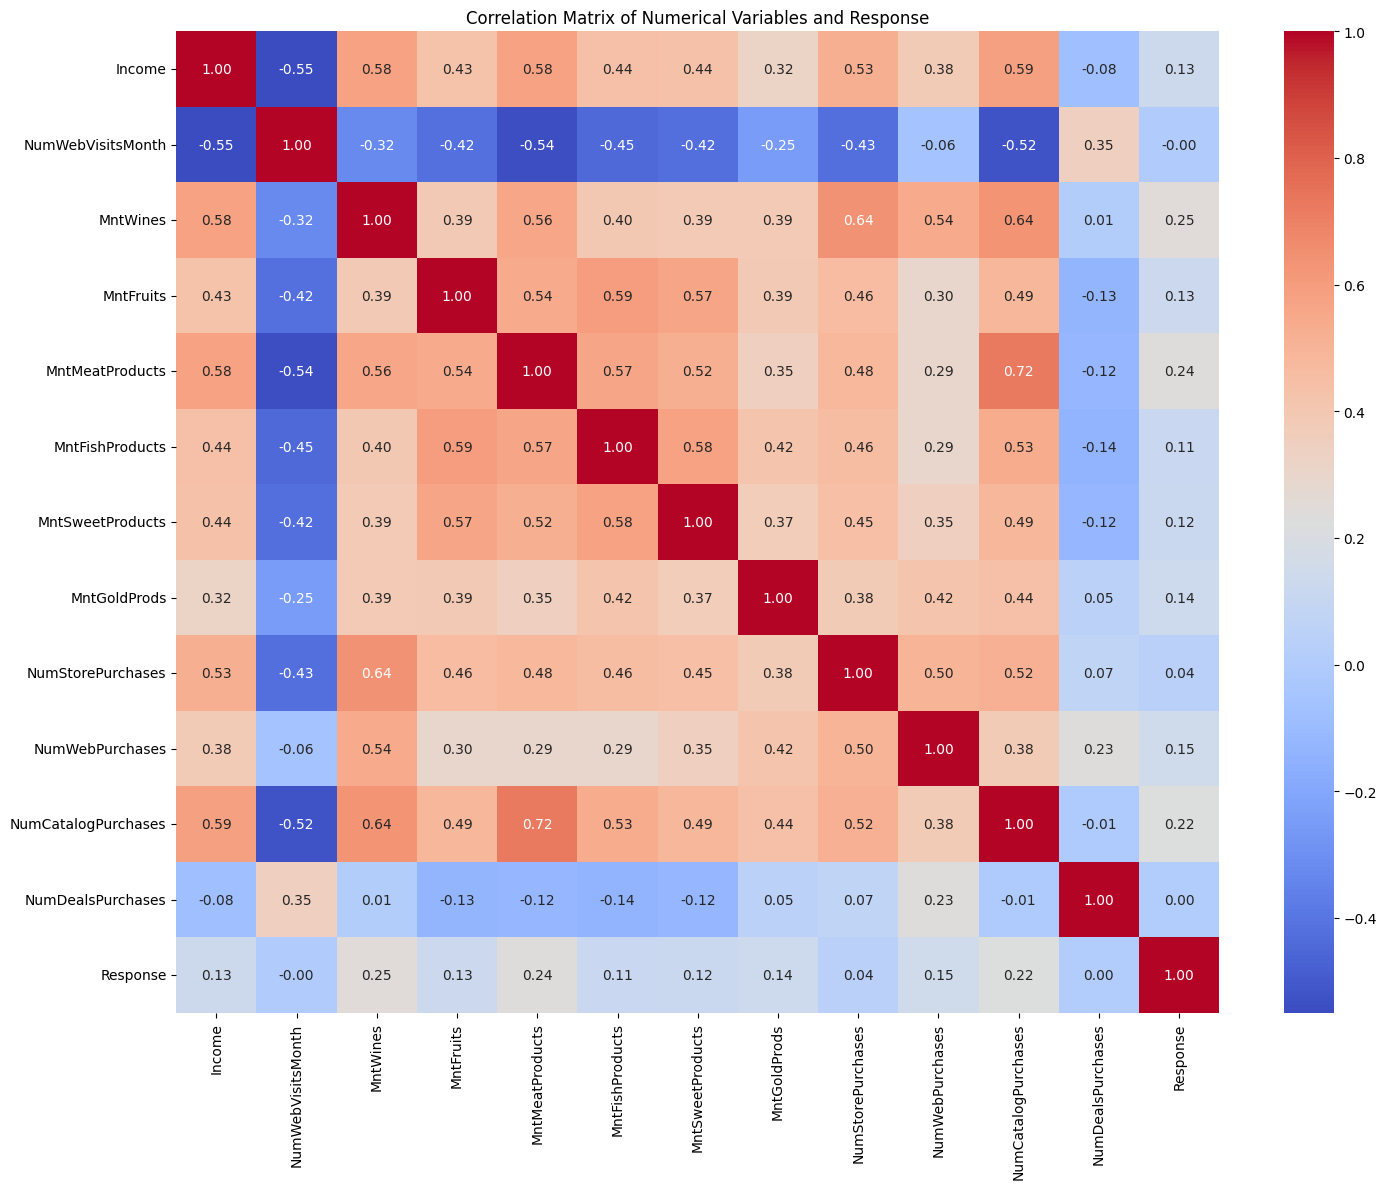

In [ ]:
# Correlation Matrix
plt.figure(figsize=(15, 12))
sns.heatmap(df[numerical_cols + ['Response']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables and Response')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

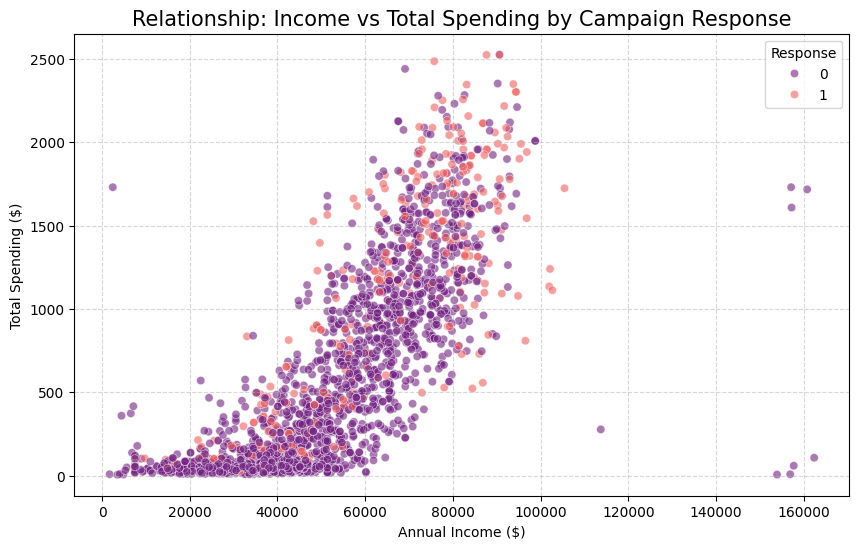

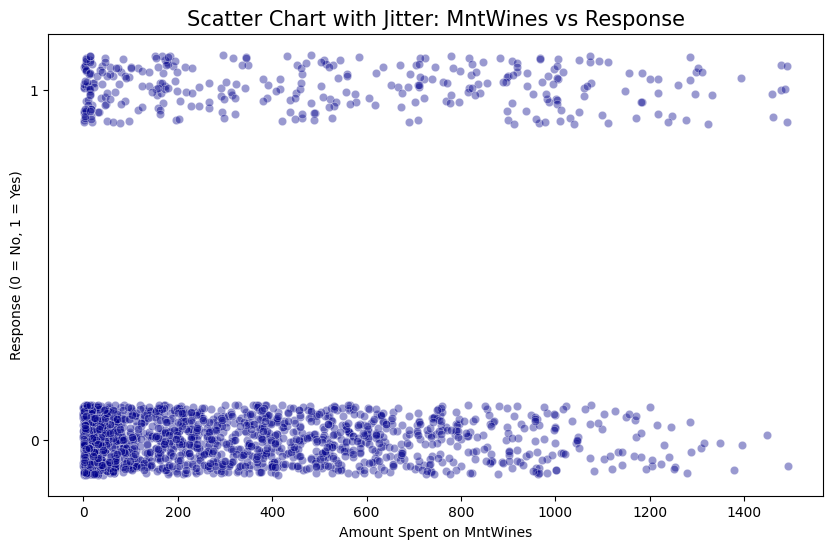

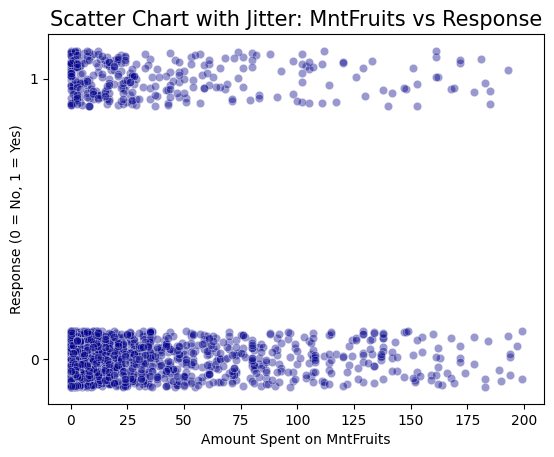

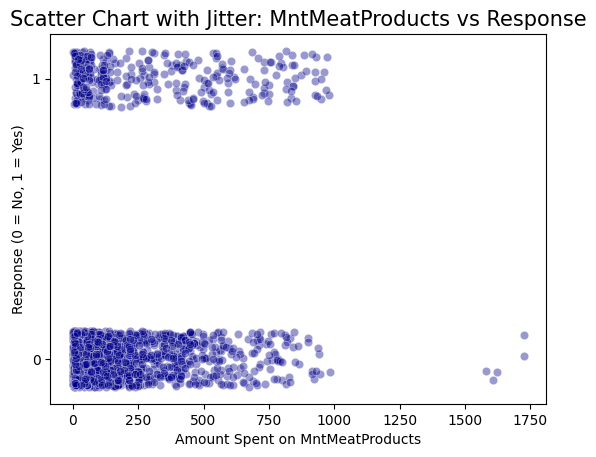

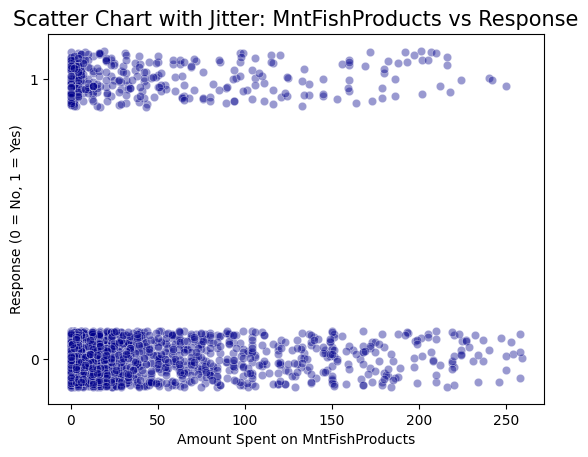

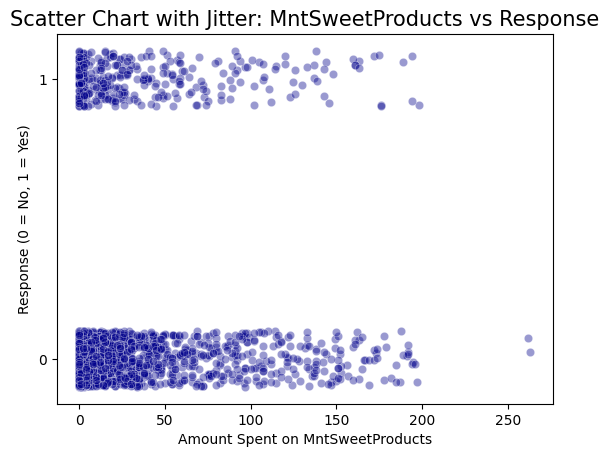

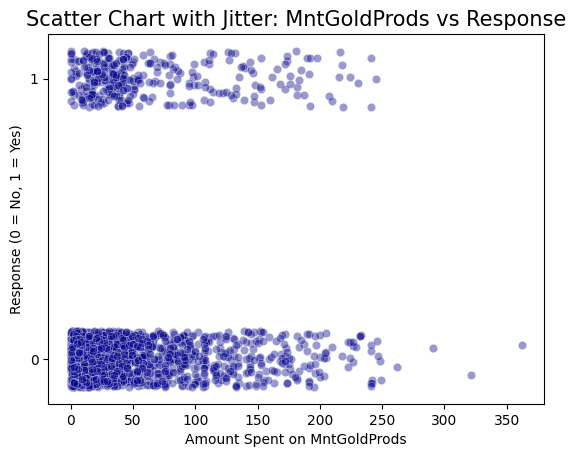

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# This line ensures that plots are displayed directly in your notebook
%matplotlib inline



# 2. Cleaning and Feature Engineering
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'] = df['Income'].fillna(df['Income'].median())

# Filter extreme income outlier ($666k) so the scatter plot isn't squashed
df_plot = df[df['Income'] < 200000].copy()

# Sum total spending across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_plot['TotalSpending'] = df_plot[spending_cols].sum(axis=1)

# 3. Create Scatter Chart: Income vs Total Spending
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Income', y='TotalSpending', hue='Response', alpha=0.6, palette='magma')

plt.title('Relationship: Income vs Total Spending by Campaign Response', fontsize=15)
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spending ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # In Jupyter, this displays the plot immediately

# 4. Create Scatter Chart with Jitter: MntWines vs Response

plt.figure(figsize=(10, 6))
for i, col in enumerate(spending_cols):
    # We add a small random 'jitter' to the Y-axis (Response) to see overlapping points
    sns.scatterplot(x=df_plot[col],
                    y=df_plot['Response'] + np.random.uniform(-0.1, 0.1, size=len(df_plot)),
                    alpha=0.4, color='darkblue')

    plt.title(f'Scatter Chart with Jitter: {col} vs Response', fontsize=15)
    plt.xlabel(f'Amount Spent on {col}')
    plt.ylabel('Response (0 = No, 1 = Yes)')
    plt.yticks([0, 1])
    plt.show()

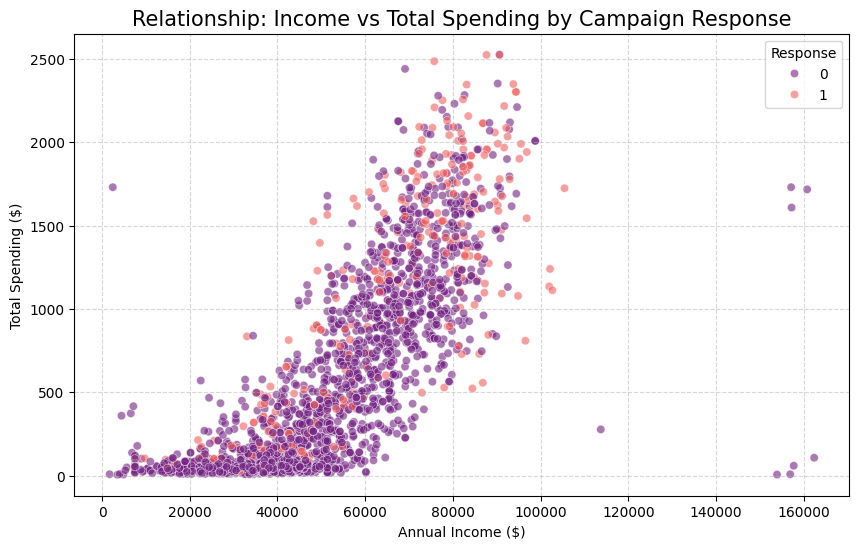

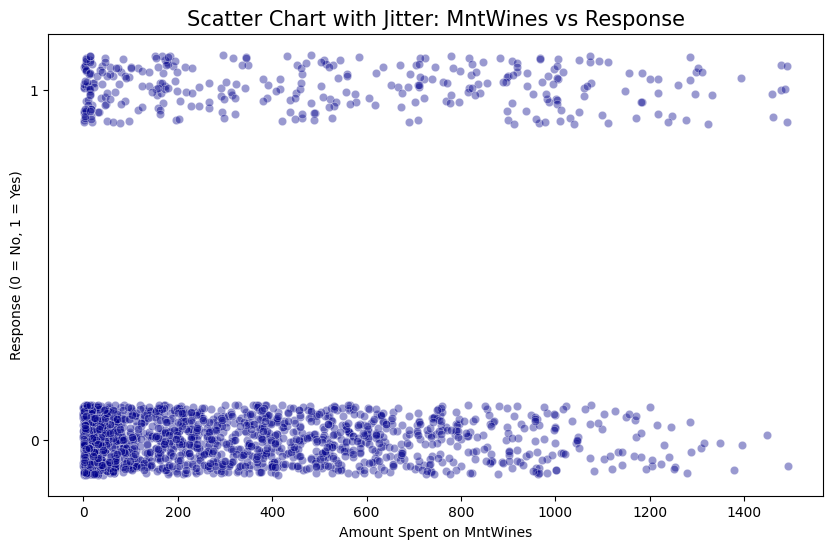

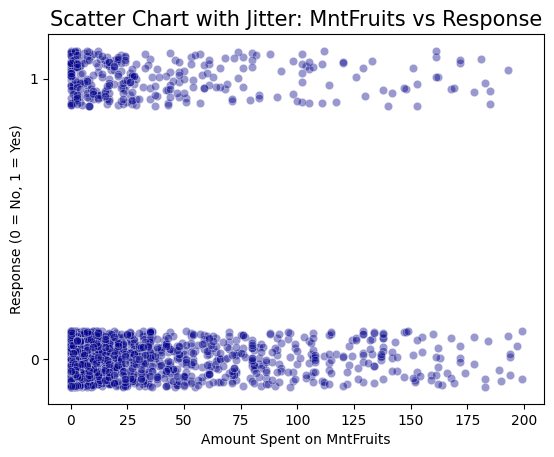

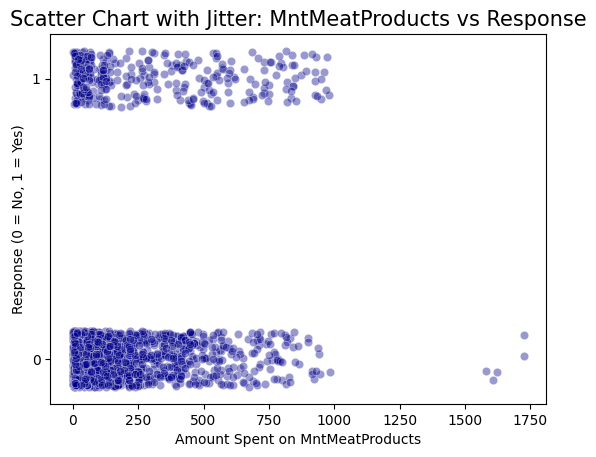

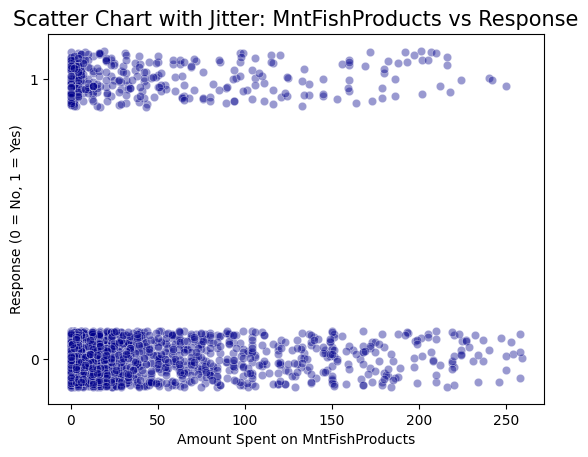

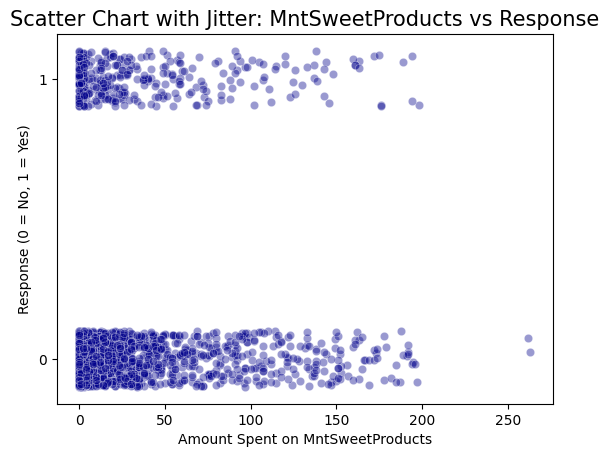

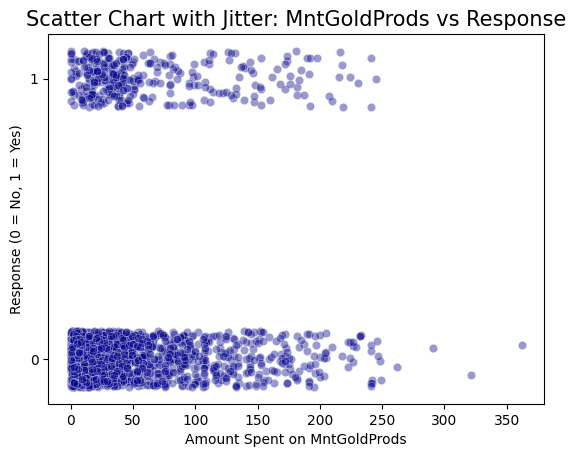

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# This line ensures that plots are displayed directly in your notebook
%matplotlib inline



# 2. Cleaning and Feature Engineering
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'] = df['Income'].fillna(df['Income'].median())

# Filter extreme income outlier ($666k) so the scatter plot isn't squashed
df_plot = df[df['Income'] < 200000].copy()

# Sum total spending across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_plot['TotalSpending'] = df_plot[spending_cols].sum(axis=1)

# 3. Create Scatter Chart: Income vs Total Spending
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Income', y='TotalSpending', hue='Response', alpha=0.6, palette='magma')

plt.title('Relationship: Income vs Total Spending by Campaign Response', fontsize=15)
plt.xlabel('Annual Income ($)')
plt.ylabel('Total Spending ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # In Jupyter, this displays the plot immediately

# 4. Create Scatter Chart with Jitter: MntWines vs Response

plt.figure(figsize=(10, 6))
for i, col in enumerate(spending_cols):
    # We add a small random 'jitter' to the Y-axis (Response) to see overlapping points
    sns.scatterplot(x=df_plot[col],
                    y=df_plot['Response'] + np.random.uniform(-0.1, 0.1, size=len(df_plot)),
                    alpha=0.4, color='darkblue')

    plt.title(f'Scatter Chart with Jitter: {col} vs Response', fontsize=15)
    plt.xlabel(f'Amount Spent on {col}')
    plt.ylabel('Response (0 = No, 1 = Yes)')
    plt.yticks([0, 1])
    plt.show()

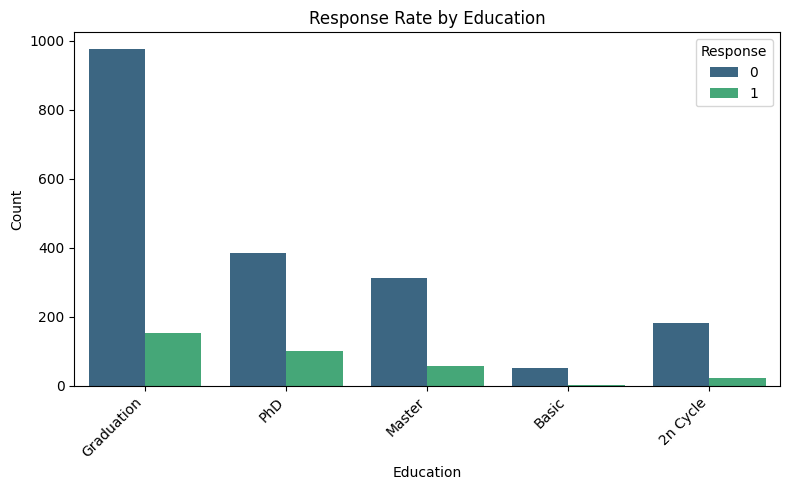


Chi-square test for Education vs Response:
Chi-square statistic: 23.08
P-value: 0.000
There is a significant relationship between Education and Response (p < 0.05).


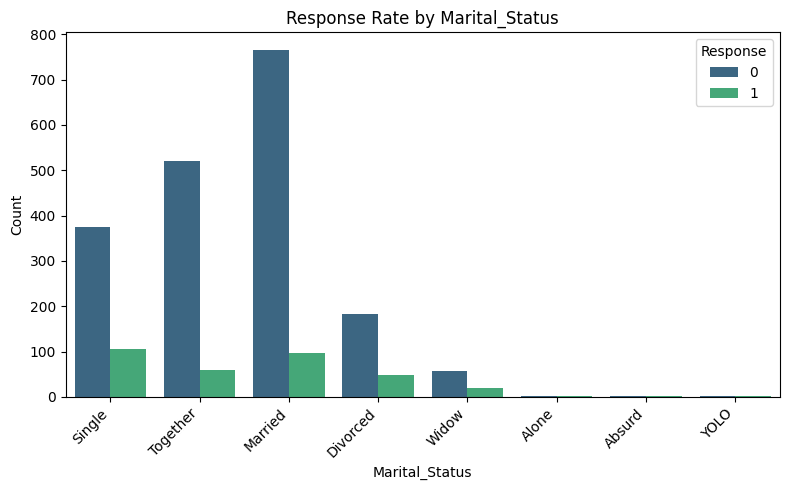


Chi-square test for Marital_Status vs Response:
Chi-square statistic: 54.24
P-value: 0.000
There is a significant relationship between Marital_Status and Response (p < 0.05).


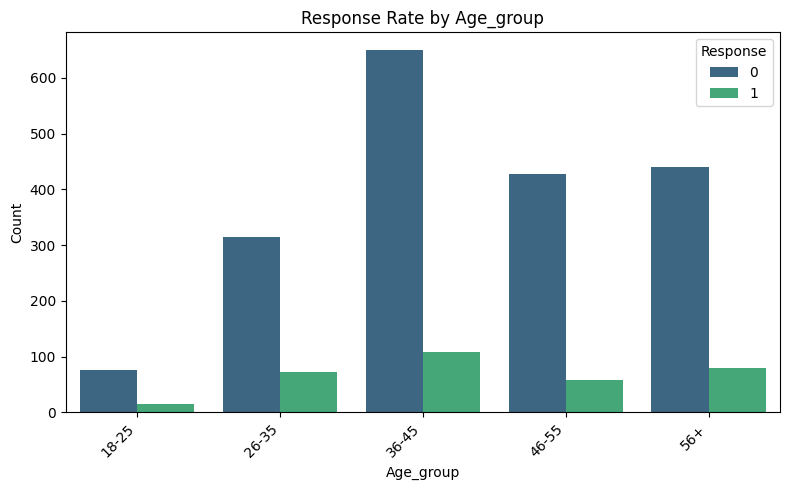


Chi-square test for Age_group vs Response:
Chi-square statistic: 7.59
P-value: 0.108
There is no significant relationship between Age_group and Response (p >= 0.05).


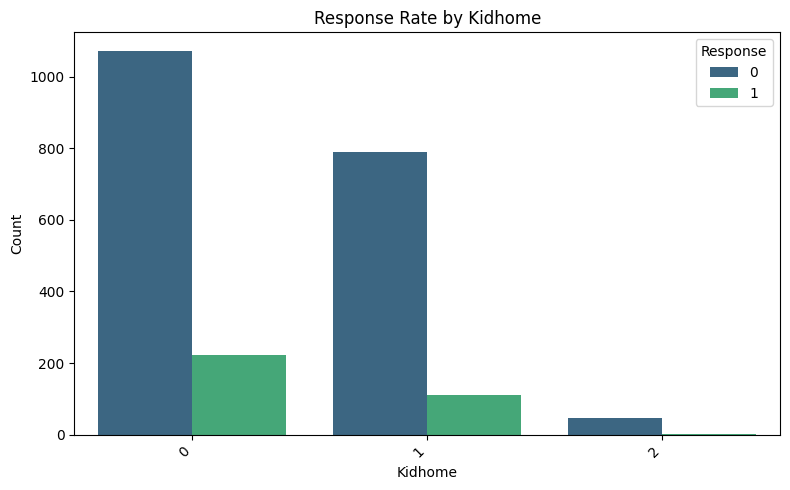


Chi-square test for Kidhome vs Response:
Chi-square statistic: 14.64
P-value: 0.001
There is a significant relationship between Kidhome and Response (p < 0.05).


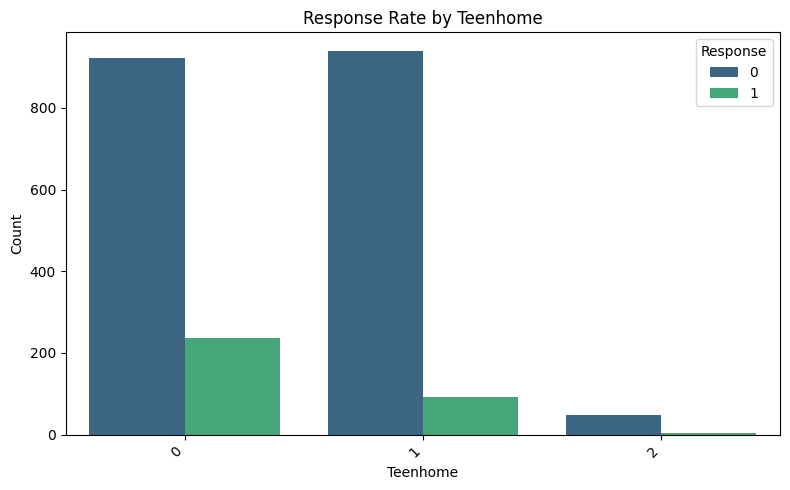


Chi-square test for Teenhome vs Response:
Chi-square statistic: 58.34
P-value: 0.000
There is a significant relationship between Teenhome and Response (p < 0.05).


In [ ]:
import scipy.stats as sc

categorical_cols = ['Education', 'Marital_Status', 'Age_group', 'Kidhome', 'Teenhome'] # Exclude Response and Complain for this analysis as Response is target and Complain is a binary outcome already analyzed

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Response', palette='viridis')
    plt.title(f'Response Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Response')
    plt.tight_layout()
    plt.show()

    print(f"\nChi-square test for {col} vs Response:")
    contingency_table = pd.crosstab(df[col], df['Response'])
    chi2, p_value, _, _ = sc.chi2_contingency(contingency_table)
    print(f"Chi-square statistic: {chi2:.2f}")
    print(f"P-value: {p_value:.3f}")
    if p_value < 0.05:
        print(f"There is a significant relationship between {col} and Response (p < 0.05).")
    else:
        print(f"There is no significant relationship between {col} and Response (p >= 0.05).")

/tmp/ipython-input-1118662755.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df, palette='viridis')
/tmp/ipython-input-1118662755.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df, palette='viridis')
/tmp/ipython-input-1118662755.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df, palette='viridis')
/tmp/ipython-input-1118662755.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

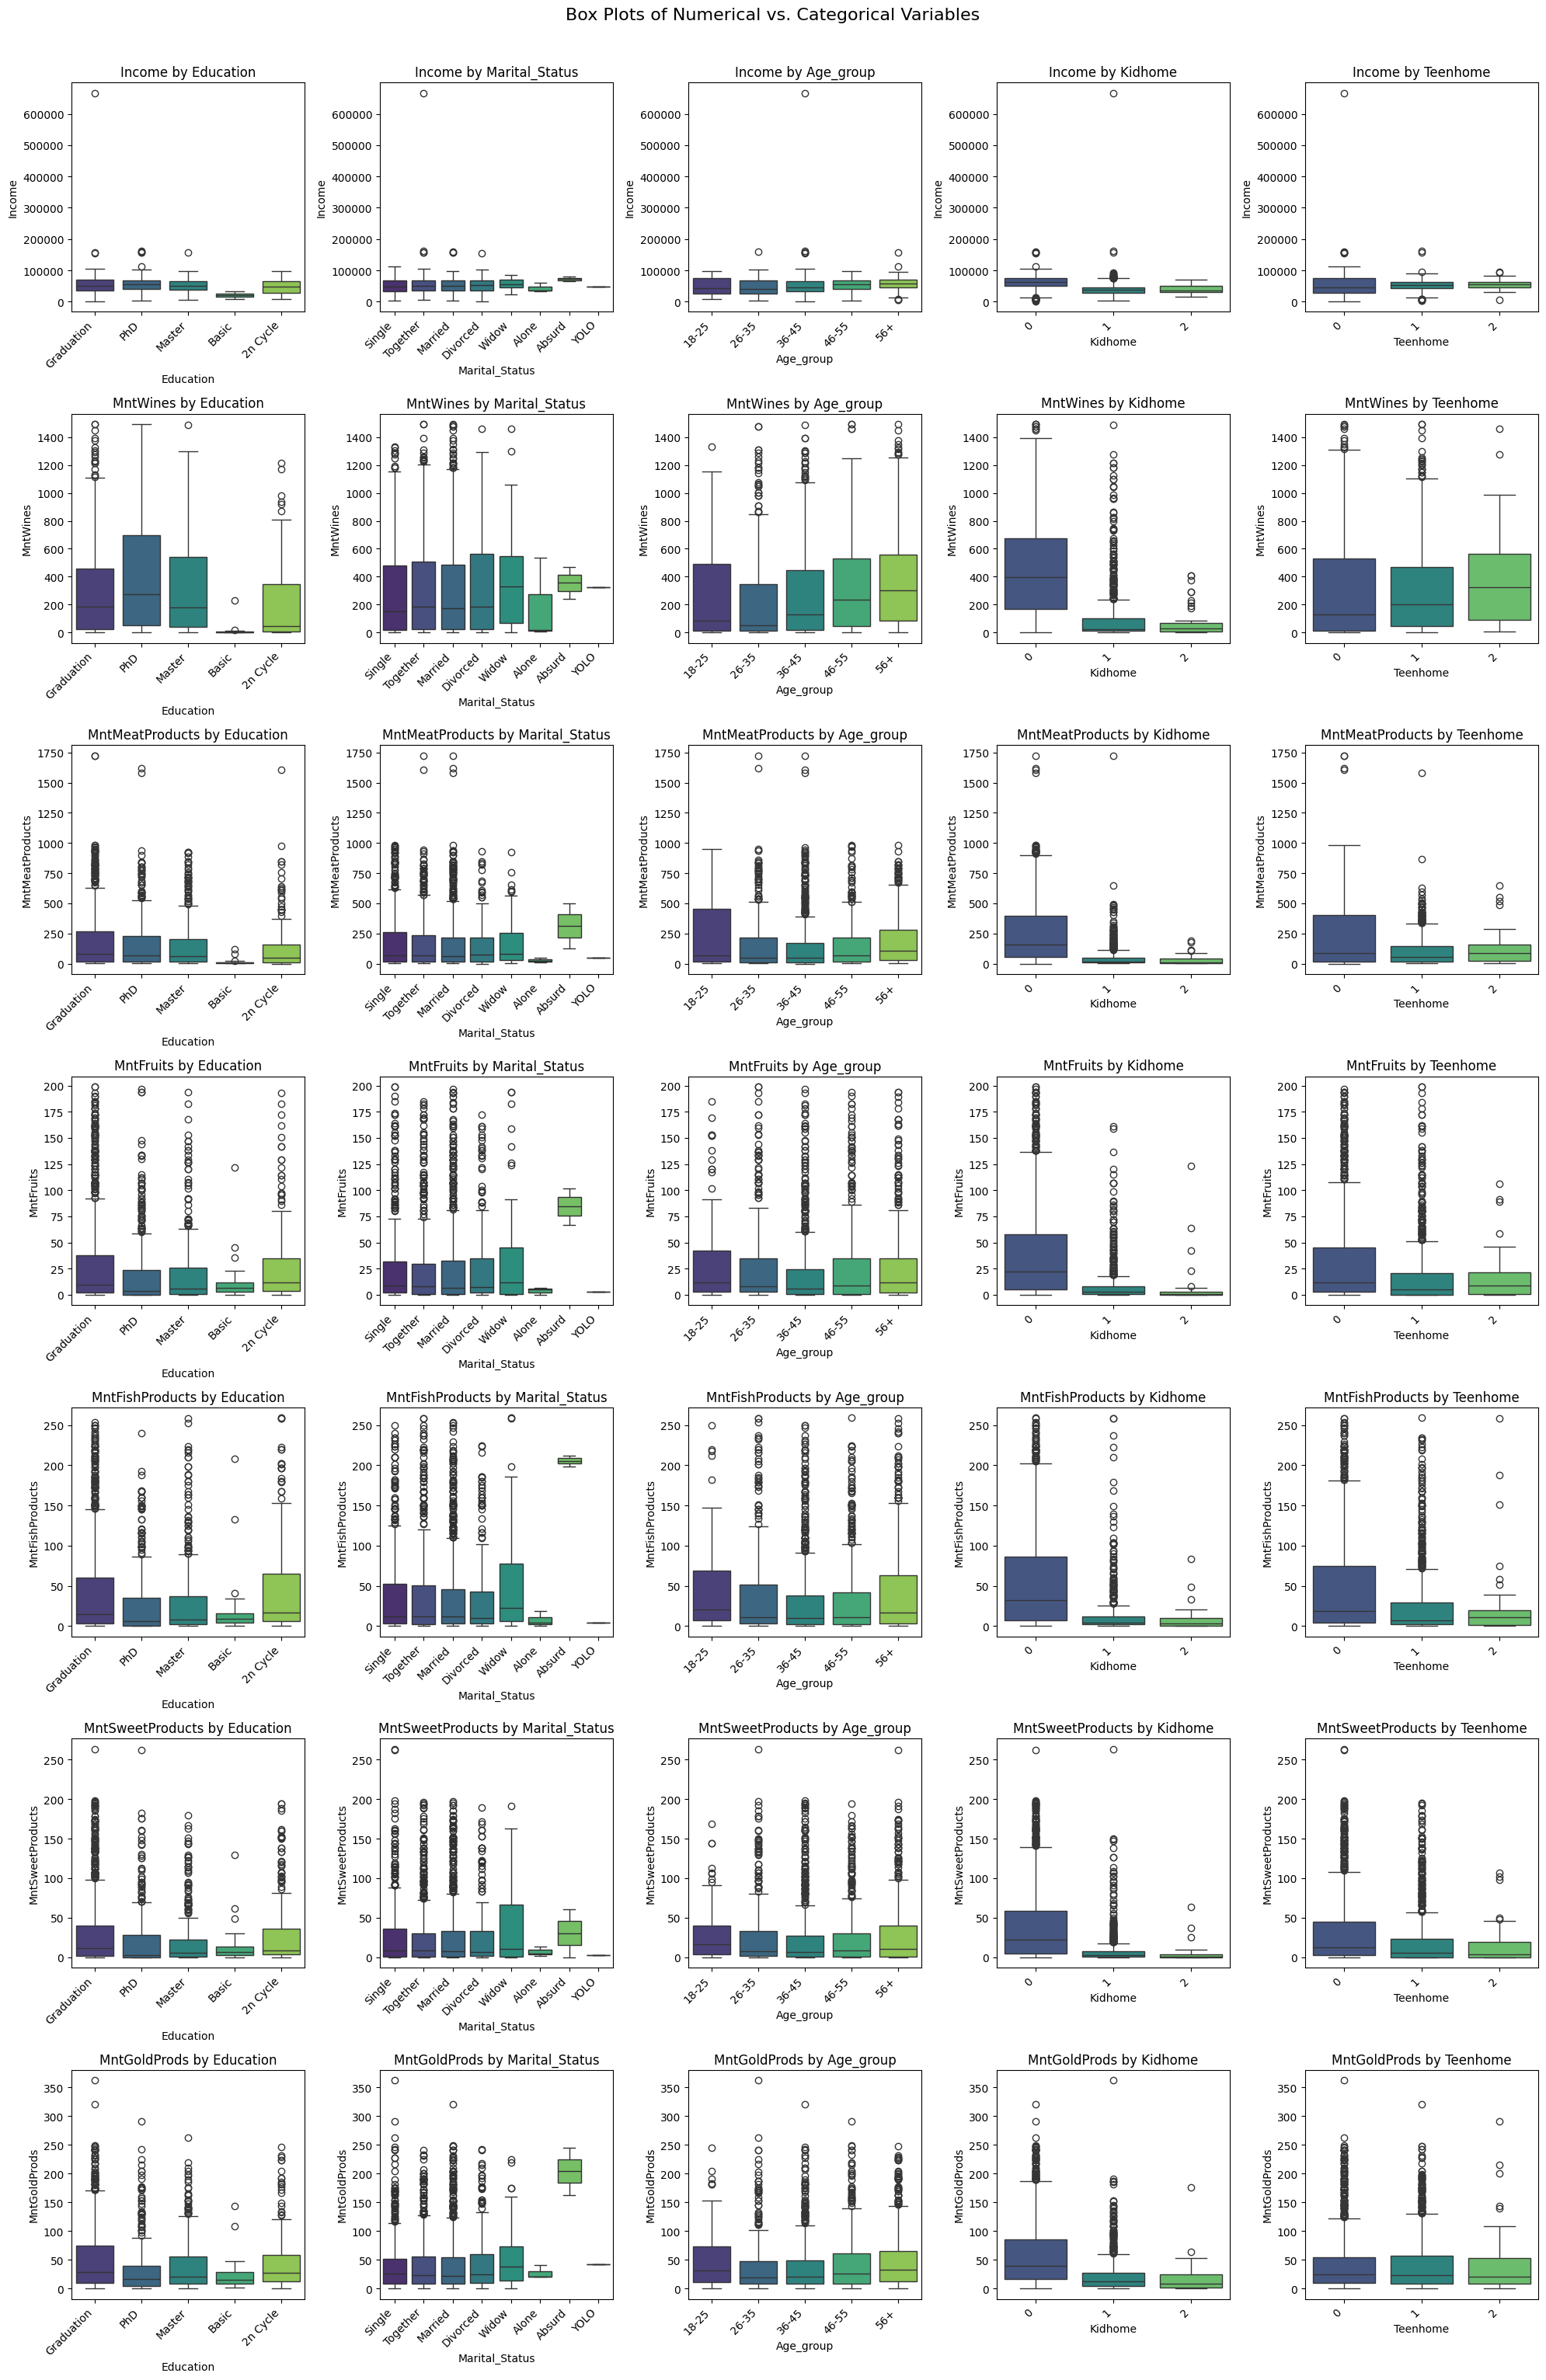

In [ ]:
# Define numerical and categorical columns for this analysis
selected_numerical_cols = ['Income', 'MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
selected_categorical_cols = ['Education', 'Marital_Status', 'Age_group', 'Kidhome', 'Teenhome']

# Convert Kidhome and Teenhome to category type for proper plotting
df['Kidhome'] = df['Kidhome'].astype('category')
df['Teenhome'] = df['Teenhome'].astype('category')

# --- Generate Box Plots ---
plt.figure(figsize=(20, 30))
n_rows_box = len(selected_numerical_cols)
n_cols_box = len(selected_categorical_cols)

plot_index = 1
for num_col in selected_numerical_cols:
    for cat_col in selected_categorical_cols:
        plt.subplot(n_rows_box, n_cols_box, plot_index)
        sns.boxplot(x=cat_col, y=num_col, data=df, palette='viridis')
        plt.title(f'{num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plot_index += 1
plt.tight_layout()
plt.suptitle('Box Plots of Numerical vs. Categorical Variables', y=1.02, fontsize=16)
plt.savefig('numerical_categorical_boxplots.png')
plt.show()


/tmp/ipython-input-740593763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=cat_col, y=num_col, data=df, palette='plasma')
/tmp/ipython-input-740593763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=cat_col, y=num_col, data=df, palette='plasma')
/tmp/ipython-input-740593763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=cat_col, y=num_col, data=df, palette='plasma')
/tmp/ipython-input-740593763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

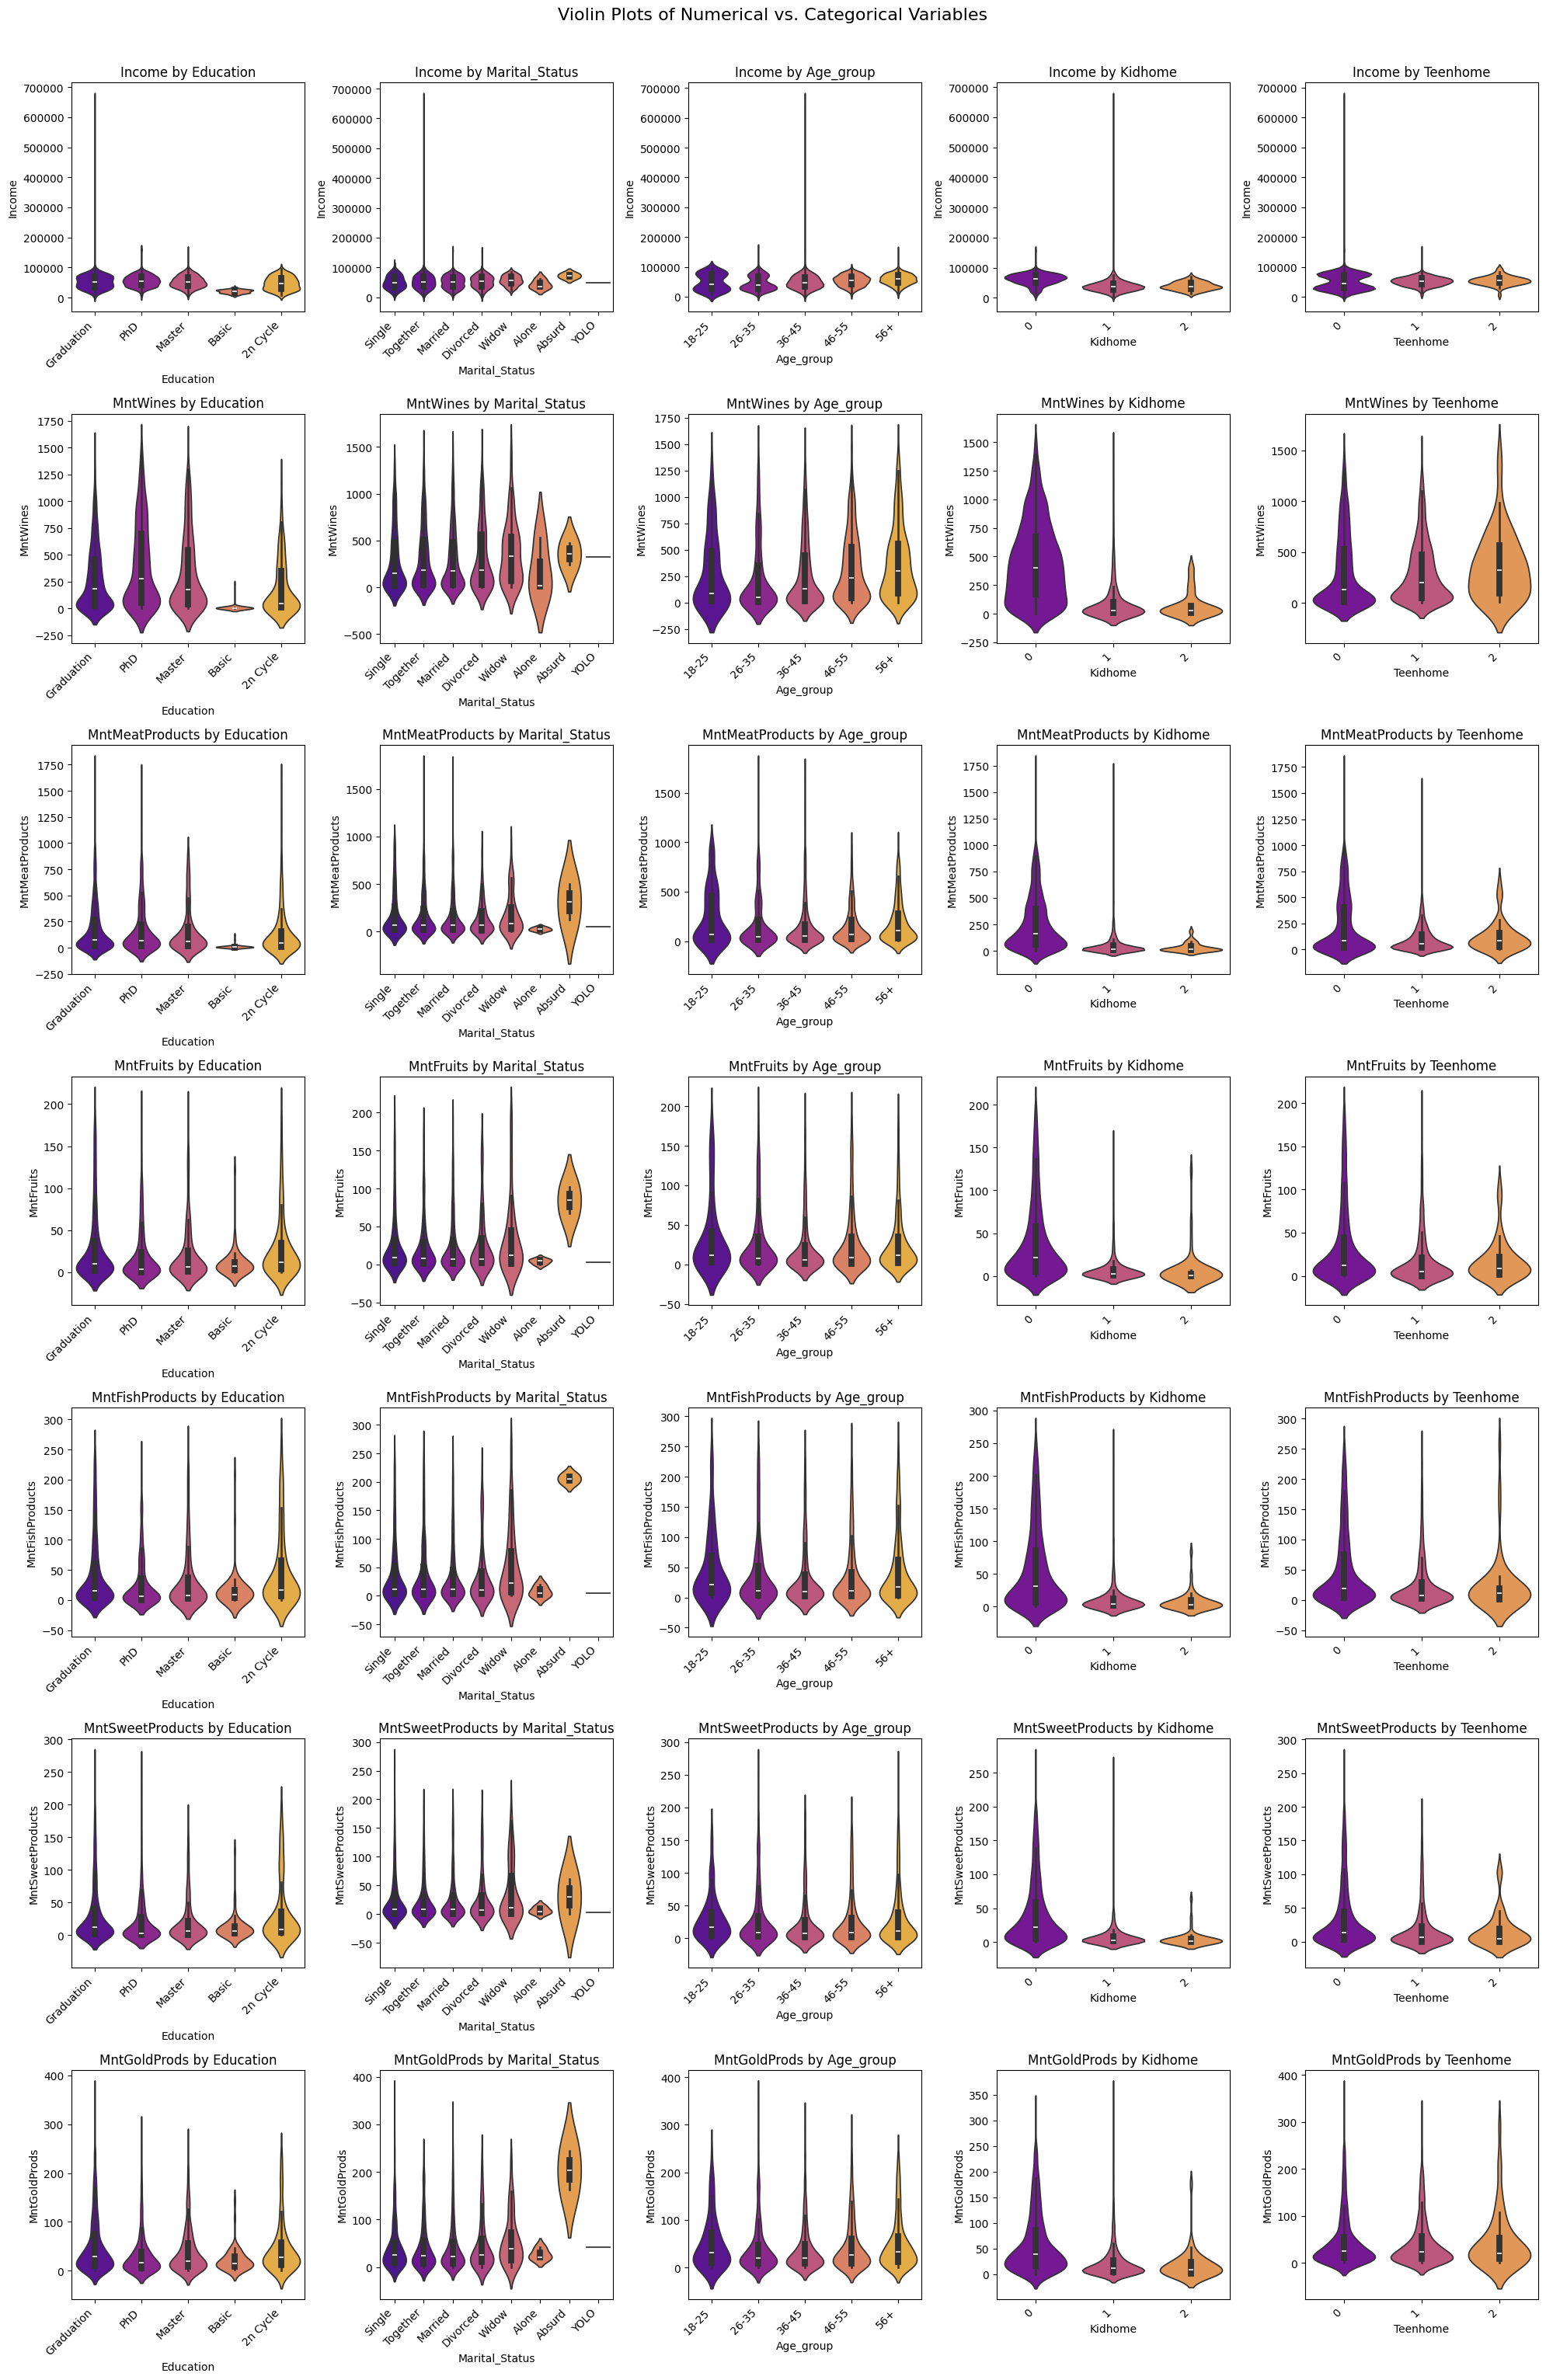

In [ ]:
# --- Generate Violin Plots ---
plt.figure(figsize=(20, 30))
n_rows_violin = len(selected_numerical_cols)
n_cols_violin = len(selected_categorical_cols)

plot_index = 1
for num_col in selected_numerical_cols:
    for cat_col in selected_categorical_cols:
        plt.subplot(n_rows_violin, n_cols_violin, plot_index)
        sns.violinplot(x=cat_col, y=num_col, data=df, palette='plasma')
        plt.title(f'{num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plot_index += 1
plt.tight_layout()
plt.suptitle('Violin Plots of Numerical vs. Categorical Variables', y=1.02, fontsize=16)
plt.savefig('numerical_categorical_violinplots.png')
plt.show()


# Exploratory Data Analysis Report: Marketing Campaign System for Retail Analytics

## 1. Introduction
This report summarizes the Exploratory Data Analysis (EDA) conducted on the `marketing_campaign.csv` dataset. The primary goal of this EDA is to understand the underlying patterns, distributions, and relationships within the data, which will serve as a foundational step for building an effective marketing campaign system for retail analytics.

## 2. Data Loading and Initial Inspection
- The `marketing_campaign.csv` file was successfully loaded into a pandas DataFrame named `df`.
- Initial inspection using `df.head()` revealed the first few rows, providing a glimpse into the dataset's structure.
- `df.info()` showed that the dataset contains 2240 entries and 27 columns. Data types include `int64`, `float64`, and `object` (strings).

## 3. Data Cleaning
- **Missing Values**: An assessment for missing values using `df.isnull().sum()` revealed 24 missing values in the `Income` column.
- **Imputation**: These 24 missing `Income` values were imputed by replacing them with the mean of the `Income` column. This ensures data completeness without significantly altering the overall distribution of the income feature.
- **Warnings**: A `FutureWarning` from pandas regarding `inplace=True` was noted, but it does not affect the correctness of the imputation.

## 4. Descriptive Statistics
- `df.describe()` provided key statistical summaries for all numerical columns, including count, mean, standard deviation, minimum, 25th percentile, 50th percentile (median), 75th percentile, and maximum values. This gave an overview of the central tendency, dispersion, and range of each numerical feature.

## 5. Numerical Variable Analysis
### Distributions (Histograms and Box Plots)
- Histograms were generated for all numerical columns to visualize their distributions. Many spending-related features (`MntWines`, `MntMeatProducts`, etc.) showed right-skewed distributions, indicating that most customers spend lower amounts, with a few high-spending customers. `Income` also exhibited a right-skewed distribution.
- Box plots were used to identify outliers in numerical variables. Columns like `Income`, `Year_Birth`, and several `Mnt` (amount spent) columns showed clear outliers, suggesting a need for potential outlier treatment or robust modeling techniques in future steps. An extreme `Income` outlier (666k) was noted and temporarily filtered for specific visualizations to avoid squashing the plots.

### Relationship with Target Variable ('Response')
- **Scatter Plots (`numerical_vs_response_scatter.png`)**: Scatter plots of each numerical feature against the `Response` variable (binary: 0 or 1) were generated. These plots helped visualize potential linear or non-linear relationships. For instance, higher spending on certain products (e.g., `MntWines`) seemed to correlate with a higher likelihood of response.
- **Correlation Matrix (`correlation_matrix.png`)**: A heatmap of the correlation matrix was created for all numerical variables, including `Response`. This showed:
    - Strong positive correlations among various spending categories (e.g., `MntWines` and `MntMeatProducts`).
    - Positive correlations between `Income` and several spending categories.
    - Moderate positive correlations between certain spending habits (e.g., `MntWines`, `MntMeatProducts`) and `Response`, indicating that customers who spend more are more likely to respond to a campaign.

## 6. Categorical Variable Analysis
### Feature Engineering
- The `Dt_Customer` column was converted to datetime format.
- An `Age` column was derived from `Year_Birth` (using 2014 as a reference year).
- An `Age_group` column was created by categorizing `Age` into bins: '18-25', '26-35', '36-45', '46-55', and '56+'.

### Distributions (Bar Plots and Pie Charts)
- Bar plots (`categorical_bar_plots.png`) and pie charts (`categorical_pie_charts.png`) were generated for categorical variables: `Education`, `Marital_Status`, `Age_group`, `Response`, and `Complain`.
    - **Education**: Showed the proportion of customers across different education levels (e.g., Graduation, PhD, Master).
    - **Marital_Status**: Highlighted the distribution of marital statuses (e.g., Married, Together, Single).
    - **Age_group**: Illustrated the age demographics of the customer base.

### Relationship with Target Variable ('Response') and Chi-square Tests
- Bar plots showing `Response` rate by each categorical variable (`Education`, `Marital_Status`, `Age_group`, `Kidhome`, `Teenhome`) were generated.
- **Chi-square tests** were performed to statistically assess the independence between each categorical variable and `Response`:
    - **Education vs. Response**: Significant relationship (p < 0.05), suggesting education level influences campaign response.
    - **Marital_Status vs. Response**: Significant relationship (p < 0.05), indicating marital status is associated with response.
    - **Age_group vs. Response**: No significant relationship (p >= 0.05) found at the 0.05 significance level, implying age group alone might not be a strong predictor.
    - **Kidhome vs. Response**: Significant relationship (p < 0.05), suggesting the number of kids at home influences response.
    - **Teenhome vs. Response**: Significant relationship (p < 0.05), suggesting the number of teens at home influences response.

## 7. Numerical vs. Categorical Variable Analysis
- Box plots (`numerical_categorical_boxplots.png`) and Violin plots (`numerical_categorical_violinplots.png`) were generated to examine the distributions of numerical spending variables across different categories of `Education`, `Marital_Status`, `Age_group`, `Kidhome`, and `Teenhome`.
    - These plots provided insights into how spending patterns (e.g., `MntWines`, `Income`) vary based on demographic factors (e.g., customers with higher education or specific marital statuses might have different income and spending profiles).
    - For instance, income and spending on various products generally tend to be higher for customers with higher education levels or those without kids/teens at home.

## 8. Key Insights and Next Steps
**Key Insights**:
- **Income and Spending**: `Income` is a crucial factor, positively correlated with overall spending and potentially influencing campaign response. Outliers in `Income` and spending indicate a segment of high-value customers.
- **Demographics**: `Education`, `Marital_Status`, `Kidhome`, and `Teenhome` all show a statistically significant relationship with campaign `Response`, highlighting their importance in segmenting customers and tailoring campaigns.
- **Age Group**: While `Age_group` itself didn't show a significant direct relationship with `Response` in the Chi-square test, its interaction with spending patterns might still be relevant.
- **Campaign Effectiveness**: Certain spending behaviors (e.g., higher wine or meat product spending) are positively associated with `Response`.

**Next Steps**:
- **Feature Engineering**: Further feature engineering could involve creating total spending features, family size, or age of customer when they first enrolled (`Dt_Customer`). Interaction terms between significant features could also be explored.
- **Outlier Treatment**: Address outliers in numerical features (e.g., Winsorization, transformation) or use models robust to outliers.
- **Modeling**: Utilize the insights gained to build predictive models for campaign response, starting with logistic regression, decision trees, or ensemble methods.
- **Customer Segmentation**: Based on demographic and spending patterns, customer segments can be defined to personalize future marketing strategies.


In [ ]:
print('Distribution of Education Levels:')
display(df['Education'].value_counts())

print('\nDistribution of Marital Status:')
display(df['Marital_Status'].value_counts())

Distribution of Education Levels:


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54



Distribution of Marital Status:


,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2
